# 5 - TEXT PREPROCESSING 

## Phần 1- EDA cho IMDB Dataset 50K Movie Reviews
Phần này trình bày phân tích khám phá dữ liệu theo chuẩn kỹ tiền xử lý cho dữ liệu text IDMB. Trọng tâm của toàn bộ phân tích là mô tả phân phối đặc trưng, đo mức độ khác biệt giữa các lớp bằng chỉ số định lượng, và rút ra hàm ý trực tiếp cho bước biểu diễn đặc trưng và lựa chọn mô hình.

### 1. Tổng quan:
#### 1.1. Chủ đề dữ liệu

Bộ dữ liệu IMDb 50K Movie Reviews tập trung vào bài toán dự đoán cảm xúc (sentiment analysis) của người dùng dựa trên các bài đánh giá phim. Mỗi mẫu dữ liệu bao gồm nội dung văn bản của một bài review và nhãn cảm xúc tương ứng (tích cực hoặc tiêu cực).

Dữ liệu thuộc lĩnh vực xử lý ngôn ngữ tự nhiên (Natural Language Processing - NLP), phản ánh cách người dùng thể hiện quan điểm, cảm nhận và đánh giá đối với một bộ phim thông qua ngôn ngữ tự nhiên. Các yếu tố như từ ngữ, ngữ cảnh, cấu trúc câu và sắc thái biểu đạt đều ảnh hưởng đến việc xác định cảm xúc.

Trong bối cảnh thực tế, bộ dữ liệu này đại diện cho cách các nền tảng trực tuyến và doanh nghiệp khai thác dữ liệu văn bản để giải quyết các bài toán như:

- Phân tích phản hồi khách hàng
- Đánh giá chất lượng sản phẩm/dịch vụ
- Theo dõi xu hướng và dư luận người dùng

Bài toán đặt ra là xây dựng mô hình có khả năng tự động phân loại cảm xúc từ văn bản, từ đó hỗ trợ quá trình ra quyết định dựa trên dữ liệu.

#### 1.2. Nguồn dữ liệu
- Nền tảng: Kaggle
- Tên bộ dữ liệu: IMDb Dataset of 50K Movie Reviews
- URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
- Tác giả: Lakshmi Narayanan Pathi (tổng hợp từ IMDb)
- Nguồn công bố: Dữ liệu đánh giá phim từ Internet Movie Database (IMDb)
- Năm cập nhật: 2018 (phiên bản phổ biến trên Kaggle)

Dữ liệu đã được tiền xử lý cơ bản và cân bằng nhãn, phù hợp cho các bài toán phân loại nhị phân.

#### 1.3. Lý do chọn dataset

Việc lựa chọn bộ dữ liệu IMDb 50K Movie Reviews xuất phát từ nhiều lý do quan trọng về cả mặt học thuật và ứng dụng thực tiễn.
- Thứ nhất, bài toán phân tích cảm xúc là một trong những bài toán cốt lõi của lĩnh vực xử lý ngôn ngữ tự nhiên, có tính ứng dụng rộng rãi trong nhiều ngành công nghiệp. Việc hiểu và phân loại cảm xúc từ văn bản giúp các tổ chức khai thác hiệu quả dữ liệu phi cấu trúc ngày càng gia tăng trên Internet.

- Thứ hai, bộ dữ liệu có quy mô đủ lớn và được gán nhãn rõ ràng, giúp thuận lợi trong việc huấn luyện và đánh giá mô hình. Đặc biệt, dữ liệu văn bản trong dataset mang tính tự nhiên cao, bao gồm nhiều cách diễn đạt khác nhau như:
    - Ngôn ngữ không chính thức
    - Từ lóng và biểu cảm cá nhân
    - Câu văn phức tạp và đa nghĩa

    Điều này giúp mô hình học được các đặc trưng ngôn ngữ gần với thực tế hơn.

- Thứ ba, dataset này phù hợp để triển khai và so sánh nhiều phương pháp khác nhau, từ các mô hình truyền thống như:

    - Naive Bayes
    - Logistic Regression

    đến các mô hình học sâu hiện đại như:

    - LSTM
    - Transformer (BERT)

Qua đó, người học có thể hiểu rõ sự khác biệt về hiệu năng, độ phức tạp và khả năng tổng quát hóa của từng phương pháp.

Cuối cùng, nghiên cứu bộ dữ liệu này mang lại nhiều giá trị thực tiễn:

- Hỗ trợ hệ thống gợi ý nội dung
- Phân tích trải nghiệm người dùng
- Tự động tổng hợp và đánh giá phản hồi

Tổng thể, đây là một bộ dữ liệu tiêu biểu, dễ tiếp cận nhưng vẫn đủ độ phức tạp để phục vụ việc học tập và nghiên cứu trong lĩnh vực khoa học dữ liệu và trí tuệ nhân tạo, đặc biệt là xử lý ngôn ngữ tự nhiên.

### Câu hỏi phân tích xuyên suốt
Phân tích được tổ chức theo chuỗi câu hỏi kỹ thuật liên kết chặt với mô hình hóa. 
- Câu hỏi thứ nhất là liệu hai lớp có khác biệt đáng kể về phân phối độ dài hay không, vì đây là một nguồn tín hiệu tiềm năng cho bộ phân loại tuyến tính. 
- Câu hỏi thứ hai là mức độ phân biệt của từ đơn so với cụm từ ngữ cảnh, nhằm đánh giá giới hạn của unigram và giá trị gia tăng của n-gram. 
- Câu hỏi thứ ba là mức đa dạng từ vựng và mức chồng lấn giữa hai lớp, từ đó ước lượng độ khó của biên phân lớp trong không gian đặc trưng.

Mục tiêu cuối cùng là chuyển các quan sát EDA thành quyết định có thể hành động trong pipeline NLP, thay vì dừng ở mô tả hiện tượng.

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from scipy.stats import mannwhitneyu, linregress
from wordcloud import WordCloud
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/raw/IMDB/IMDB Dataset.csv"
RANDOM_STATE = 42

raw_df = pd.read_csv(DATA_PATH)

text_col = "text" if "text" in raw_df.columns else ("review" if "review" in raw_df.columns else raw_df.columns[0])
label_col = "label" if "label" in raw_df.columns else ("sentiment" if "sentiment" in raw_df.columns else raw_df.columns[1])

df = raw_df[[text_col, label_col]].copy()
df.columns = ["text", "label"]
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(str).str.lower().str.strip()

print(f"Data shape: {df.shape}")
display(df.head(3))

Data shape: (50000, 2)


,text,label
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


### 2. Tổng quan về dataset
Phần này cung cấp điểm khởi đầu định lượng cho toàn bộ phân tích. Quan sát về quy mô mẫu và phân phối lớp là điều kiện tiên quyết để diễn giải các chỉ số huấn luyện sau này một cách đúng đắn. Đồng thời, kiểm tra các lỗi cấu trúc cơ bản như missing, empty và duplicate giúp đánh giá mức độ sạch dữ liệu trước khi đi sâu vào đặc trưng ngôn ngữ.

,num_rows,num_columns,missing_text,empty_text,duplicate_text
0,50000,2,0,0,418


,count,ratio
label,,
negative,25000,0.5
positive,25000,0.5


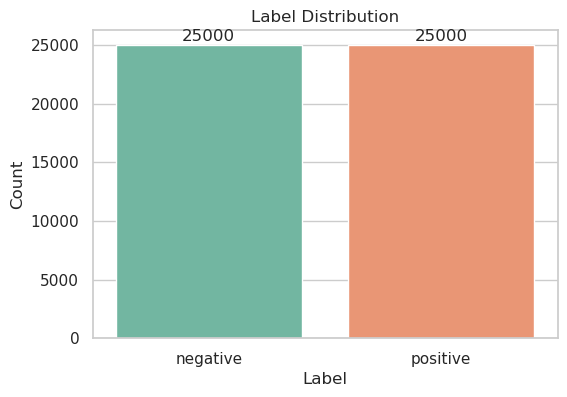

In [47]:
overview = pd.DataFrame(
    {
        "num_rows": [len(df)],
        "num_columns": [df.shape[1]],
        "missing_text": [df["text"].isna().sum()],
        "empty_text": [(df["text"].str.strip() == "").sum()],
        "duplicate_text": [df.duplicated(subset=["text"]).sum()],
    }
)

label_counts = df["label"].value_counts().sort_index()
label_ratio = (label_counts / len(df)).rename("ratio")
label_table = pd.concat([label_counts.rename("count"), label_ratio], axis=1)

display(overview)
display(label_table)

label_plot_df = label_counts.reset_index()
label_plot_df.columns = ["label", "count"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=label_plot_df, x="label", y="count", hue="label", palette="Set2", legend=False, ax=ax)
ax.set_title("Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, v in enumerate(label_plot_df["count"]):
    ax.text(i, v + 120, f"{v}", ha="center", va="bottom")
plt.show()

#### Nhận xét:
Bảng tổng quan cho thấy tập dữ liệu gồm 50,000 văn bản với hai lớp cân bằng tuyệt đối, mỗi lớp 25,000 mẫu (tỷ lệ 0.5–0.5). Điều này cho thấy rủi ro lệch nhãn ở mức thấp, do đó độ chính xác tổng thể không bị phóng đại bởi lớp đa số. Đồng thời, dữ liệu không có bản ghi rỗng hay missing nhưng có 418 văn bản trùng lặp, đây là điểm cần kiểm soát khi chia tập để tránh rò rỉ thông tin.

**Kết luận:** các chỉ số giữa thống kê đã cho thấy dữ liệu cân bằng. Nói cách khác, chất lượng mô hình phụ thuộc chủ yếu vào đặc trưng ngôn ngữ và không bị chi phối mạnh bởi phân phối nhãn.

### 3. Text Length Analysis
Phần này đánh giá đặc trưng độ dài văn bản như một nguồn tín hiệu phân biệt giữa các lớp. Trọng tâm không nằm ở giá trị trung bình đơn lẻ, mà ở cấu trúc phân phối đầy đủ gồm trung vị, độ lệch chuẩn và hình dạng đuôi phân phối. Cách tiếp cận này giúp xác định liệu khác biệt quan sát được data có đủ ổn định để chuyển thành đặc trưng đầu vào cho mô hình hay không.

#### 3.1 Feature engineering độ dài (raw text)

In [48]:
#Feature engineering độ dài (raw text)
df["num_words"] = df["text"].str.split().str.len()
df["num_chars"] = df["text"].str.len()

display(df[["text", "label", "num_words", "num_chars"]].head(3))
print(df[["num_words", "num_chars"]].describe().round(2))

,text,label,num_words,num_chars
0,One of the other reviewers has mentioned that ...,positive,307,1761
1,A wonderful little production. <br /><br />The...,positive,162,998
2,I thought this was a wonderful way to spend ti...,positive,166,926


       num_words  num_chars
count   50000.00   50000.00
mean      231.16    1309.43
std       171.34     989.73
min         4.00      32.00
25%       126.00     699.00
50%       173.00     970.00
75%       280.00    1590.25
max      2470.00   13704.00


#### 3.2 Descriptive statistics theo lớp
Thống kê mô tả được thiết kế để trả lời ba điểm kỹ thuật: độ dài trung bình giữa hai lớp khác nhau ở mức nào, xu hướng trung vị có nhất quán với trung bình hay không, và mức phân tán nội lớp lớn đến đâu. Khi mean cao hơn median trong cùng một lớp, đó là tín hiệu điển hình của phân phối lệch phải và cần được xác nhận bằng biểu đồ để tránh kết luận sai do ngoại lệ.

In [49]:
length_stats = (
    df.groupby("label")
    .agg(
        words_count=("num_words", "count"),
        words_mean=("num_words", "mean"),
        words_median=("num_words", "median"),
        words_std=("num_words", "std"),
        words_q1=("num_words", lambda s: s.quantile(0.25)),
        words_q3=("num_words", lambda s: s.quantile(0.75)),
        words_min=("num_words", "min"),
        words_max=("num_words", "max"),
        chars_mean=("num_chars", "mean"),
        chars_median=("num_chars", "median"),
    )
    .round(2)
)

display(length_stats)

,words_count,words_mean,words_median,words_std,words_q1,words_q3,words_min,words_max,chars_mean,chars_median
label,,,,,,,,,,
negative,25000,229.46,174.0,164.95,128.0,278.0,4,1522,1294.06,973.0
positive,25000,232.85,172.0,177.50,125.0,284.0,10,2470,1324.80,968.0


Quan sát từ bảng thống kê cho thấy độ dài trung bình của lớp positive là 232.85 từ, cao hơn nhẹ so với lớp negative là 229.46 từ. Tuy nhiên, trung vị lại đảo chiều với 172 từ ở lớp positive và 174 từ ở lớp negative. Vì mean lớn hơn median ở cả hai lớp, cùng độ lệch chuẩn cao (177.50 và 164.95), nên phân phối có đuôi phải dài và chịu ảnh hưởng của một nhóm văn bản rất dài.

**Kết luận:** về mặt thống kê là khác biệt giữa hai lớp có tồn tại nhưng nhỏ, trong khi biến thiên nội lớp lại lớn. Vì vậy, độ dài văn bản có thể đóng vai trò đặc trưng bổ sung nhưng khó trở thành đặc trưng quyết định nếu đứng độc lập. Vì vậy, cần kết hợp độ dài với đặc trưng từ vựng hoặc n-gram để tăng độ tách lớp thay vì kỳ vọng vào một tín hiệu đơn biến.

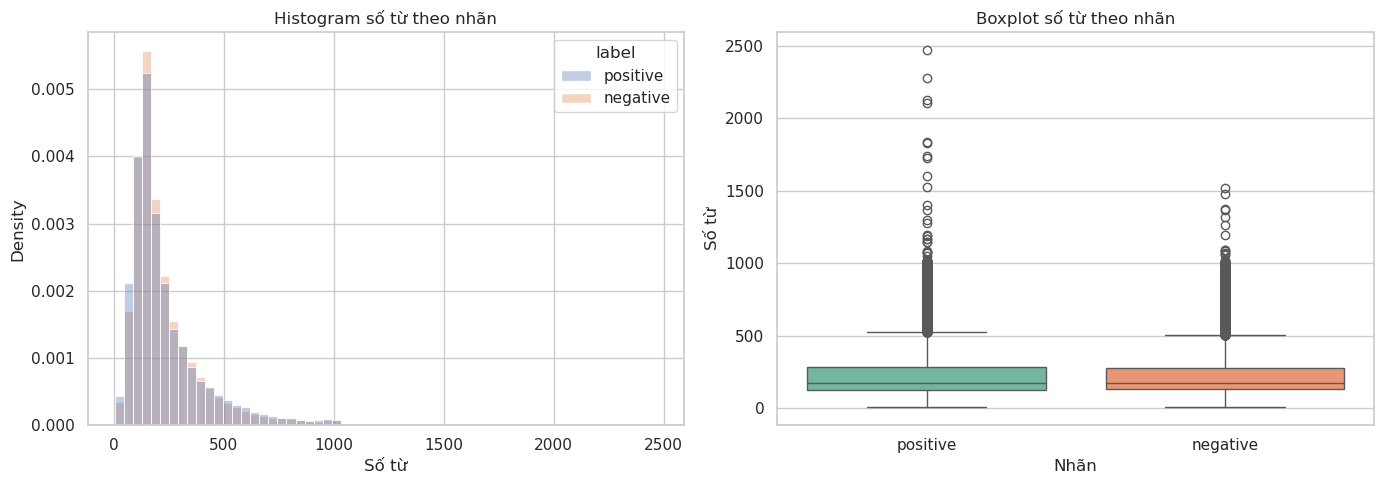

,label,q1,q3,iqr,upper_outlier_threshold,outlier_count,outlier_ratio
0,negative,128.0,278.0,150.0,503.0,1776,0.071
1,positive,125.0,284.0,159.0,522.5,1899,0.076


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="num_words",
    hue="label",
    bins=60,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Histogram số từ theo nhãn")
axes[0].set_xlabel("Số từ")

sns.boxplot(data=df, x="label", y="num_words", hue="label", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Boxplot số từ theo nhãn")
axes[1].set_xlabel("Nhãn")
axes[1].set_ylabel("Số từ")

plt.tight_layout()
plt.show()

outlier_rows = []
for lab, g in df.groupby("label"):
    q1 = g["num_words"].quantile(0.25)
    q3 = g["num_words"].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outlier_count = (g["num_words"] > upper).sum()
    outlier_rows.append(
        {
            "label": lab,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "upper_outlier_threshold": round(upper, 2),
            "outlier_count": int(outlier_count),
            "outlier_ratio": round(outlier_count / len(g), 4),
        }
    )

outlier_df = pd.DataFrame(outlier_rows)
display(outlier_df)

### Phân tích histogram và boxplot
Histogram cho thấy phân phối độ dài của cả hai lớp lệch phải rõ rệt, phù hợp với minh chứng mean lớn hơn median trong bảng mô tả. Boxplot bổ sung minh chứng về mức chồng lấn lớn giữa hai lớp tại vùng IQR, đồng thời bảng outlier cho thấy tỷ lệ ngoại lệ phía trên ngưỡng IQR tương đối cao ở cả hai lớp (khoảng 7.1% và 7.6%).

**Kết luận:** dữ liệu chứa một cụm văn bản rất dài làm tăng đuôi phân phối, điều này làm cho các phương pháp giả định chuẩn hóa mạnh dễ nhạy với ngoại lệ. Từ góc nhìn mô hình, đặc trưng độ dài vẫn có giá trị vì khác biệt tồn tại có hệ thống, nhưng mức chồng lấn lớn trong boxplot cho thấy cần dựa thêm vào đặc trưng ngữ liệu để đạt phân loại ổn định. Do đó, biểu đồ xác nhận vai trò của độ dài là tín hiệu hỗ trợ thay vì tín hiệu chính.

In [51]:
pos_len = df.loc[df["label"] == "positive", "num_words"].to_numpy()
neg_len = df.loc[df["label"] == "negative", "num_words"].to_numpy()

u_stat, p_value = mannwhitneyu(pos_len, neg_len, alternative="two-sided")
n1, n2 = len(pos_len), len(neg_len)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

test_result = pd.DataFrame(
    {
        "metric": ["Mann-Whitney U", "p-value", "Rank-biserial effect size"],
        "value": [
            f"{u_stat:.2f}",
            f"{p_value:.4f}",  
            f"{rank_biserial:.4f}",
        ],
    }
)
display(test_result)

if p_value < 0.05:
    print("Kết luận: Có sự khác biệt có ý nghĩa thống kê về phân phối độ dài giữa hai lớp.")
else:
    print("Kết luận: Chưa đủ bằng chứng thống kê để kết luận hai lớp khác biệt về độ dài.")

,metric,value
0,Mann-Whitney U,308970265.00
1,p-value,0.0287
2,Rank-biserial effect size,0.0113


Kết luận: Có sự khác biệt có ý nghĩa thống kê về phân phối độ dài giữa hai lớp.


#### Phân tích kiểm định thống kê
**Nhận xét**
- Bảng `test_result` ghi nhận `Mann-Whitney U = 308970265.00`.
- `p-value = 0.0287 < 0.05`, nên khác biệt phân phối độ dài giữa hai lớp có ý nghĩa thống kê.
- `Rank-biserial = 0.0113` (xấp xỉ 0.0113), rất nhỏ.
- Từ thống kê mô tả trước đó (`mean_positive = 232.85`, `mean_negative = 229.46`, `std` khoảng 177.50 và 164.95), Cohen's d xấp xỉ 0.02.

**Phân tích**
- Mann-Whitney phù hợp vì phân phối độ dài lệch phải và có nhiều ngoại lệ, không thỏa giả định chuẩn(t-test).
- Cỡ mẫu lớn làm kiểm định rất nhạy với chênh lệch nhỏ, nên có thể xuất hiện tình huống `p-value` nhỏ nhưng `effect size` vẫn rất thấp.
- Kết quả cho thấy p-value = 0.0287 (< 0.05), vì vậy có thể kết luận sự khác biệt phân phối độ dài giữa hai lớp có ý nghĩa thống kê.
-  Tuy nhiên, hệ số hiệu ứng rank-biserial chỉ khoảng 0.0113, cho thấy cường độ khác biệt ở mức nhỏ.

**Kết luận:**
- Độ dài review có khác biệt thống kê `(p < 0.05)` nhưng `effect size` rất nhỏ → không đủ mạnh để phân tách hai lớp. Vì vậy, độ dài chỉ là tín hiệu phụ, không nên dùng làm đặc trưng chính.
- Pipeline đặc trưng nên ưu tiên tín hiệu từ token/ngram vì phản ánh trực tiếp nội dung và có khả năng phân loại tốt hơn.
- Độ dài chỉ nên đi kèm như biến hỗ trợ trong mô hình tuyến tính, không đóng vai trò quyết định.

## 4. Phân tích Word Distribution 
Mục tiêu của phần này là định lượng mức phân biệt của từ vựng theo lớp và tách tín hiệu hữu ích khỏi nhiễu tần suất cao. Phân tích được thực hiện trên token thô nhằm bảo toàn trạng thái dữ liệu gốc, từ đó quan sát trực tiếp ảnh hưởng của các token phổ biến, token phủ định và cụm điều chỉnh trong không gian đặc trưng.

In [52]:
# 4.1 Tokenization raw bằng split()
df["tokens_raw"] = df["text"].str.split()
df["tokens"] = df["tokens_raw"].apply(lambda toks: [tok.lower() for tok in toks])

counter_all = Counter(tok for toks in df["tokens"] for tok in toks)
counter_pos = Counter(tok for toks in df.loc[df["label"] == "positive", "tokens"] for tok in toks)
counter_neg = Counter(tok for toks in df.loc[df["label"] == "negative", "tokens"] for tok in toks)

# 4.2 Top-50 words
top_n = 50
top_all = pd.DataFrame(counter_all.most_common(top_n), columns=["word", "freq_all"])
top_pos = pd.DataFrame(counter_pos.most_common(top_n), columns=["word", "freq_positive"])
top_neg = pd.DataFrame(counter_neg.most_common(top_n), columns=["word", "freq_negative"])

print("Top-50 toàn bộ corpus")
display(top_all.head(50))
print("Top-50 lớp positive")
display(top_pos.head(50))
print("Top-50 lớp negative")
display(top_neg.head(50))

# Từ phân biệt mạnh theo smoothed log-ratio
vocab = set(counter_pos) | set(counter_neg)
tot_pos = sum(counter_pos.values())
tot_neg = sum(counter_neg.values())

rows = []
for w in vocab:
    fp = counter_pos[w]
    fn = counter_neg[w]
    if fp + fn < 120:
        continue
    if not w.isalpha() or len(w) < 3:
        continue
    rp = (fp + 1) / (tot_pos + len(vocab))
    rn = (fn + 1) / (tot_neg + len(vocab))
    rows.append((w, fp, fn, np.log2(rp / rn)))

logratio_df = pd.DataFrame(rows, columns=["word", "freq_pos", "freq_neg", "log2_ratio_pos_over_neg"]) \
    .sort_values("log2_ratio_pos_over_neg", ascending=False)

print("Top từ thiên về positive")
display(logratio_df.head(15))
print("Top từ thiên về negative")
display(logratio_df.tail(15).sort_values("log2_ratio_pos_over_neg"))

# Intensifiers và phủ định
cue_words = ["very", "really", "extremely", "too", "so", "not", "never", "no"]
cue_df = pd.DataFrame(
    {
        "word": cue_words,
        "freq_positive": [counter_pos[w] for w in cue_words],
        "freq_negative": [counter_neg[w] for w in cue_words],
    }
)
display(cue_df)

Top-50 toàn bộ corpus


,word,freq_all
0,the,638861
1,a,316615
2,and,313637
3,of,286661
4,to,264573
5,is,204876
6,in,179807
7,i,141587
8,this,138483
9,that,130140


Top-50 lớp positive


,word,freq_positive
0,the,326268
1,and,171379
2,a,160990
3,of,150754
4,to,129608
5,is,108994
6,in,95642
7,i,66833
8,it,64793
9,this,64167


Top-50 lớp negative


...

Top từ thiên về positive


,word,freq_pos,freq_neg,log2_ratio_pos_over_neg
735,custer,121,5,4.325988
1864,felix,127,9,3.658285
539,matthau,164,13,3.539181
59,understated,132,15,3.035496
2388,flawless,122,14,3.015837
2500,superbly,182,22,2.972351
4318,wonderfully,473,61,2.914760
2461,perfection,106,14,2.814790
4160,delightful,334,47,2.783268
1458,captures,345,50,2.742416


Top từ thiên về negative


,word,freq_pos,freq_neg,log2_ratio_pos_over_neg
905,uwe,1,143,-6.189712
583,boll,2,137,-5.543349
3639,seagal,15,289,-4.199696
382,waste,157,2468,-3.985717
3859,unfunny,23,329,-3.801146
4226,incoherent,12,159,-3.641275
1221,worst,371,4411,-3.587845
3970,wasting,24,263,-3.420325
1953,poorly,108,1130,-3.394986
2075,redeeming,52,547,-3.389898


,word,freq_positive,freq_negative
0,very,15791,11117
1,really,10332,11473
2,extremely,1022,1078
3,too,5205,6780
4,so,16095,19877
5,not,26671,30094
6,never,6174,6447
7,no,8186,14201


### Phân tích định lượng cho phân phối từ
Bảng tần suất cho thấy lớp token chức năng như `the`, `and`, `of`, `to` chiếm tỷ trọng rất lớn ở cả hai lớp, phản ánh cấu trúc chung của văn bản tiếng Anh và không đủ sức phân biệt khi dùng độc lập. Ngược lại, các token có tần suất chênh đáng kể như `not`, `no`, cùng các cụm trong bảng bigram như `not worth`, `waste of`, `must see`, `highly recommended` cho thấy tín hiệu phân biệt tập trung ở các cấu trúc cục bộ thay vì từ đơn phổ dụng.

Kết quả log-ratio cũng xác nhận tồn tại nhóm token có khả năng phân biệt cao giữa hai lớp. Điều này cho thấy rằng đặc trưng từ vựng hiệu quả cần cân bằng hai thành phần: giữ token tần suất cao để ổn định ngữ cảnh nền, đồng thời tăng trọng cho token hoặc n-gram có độ lệch phân phối lớn. Vì vậy, các biểu diễn dựa tần suất có trọng số, đặc biệt khi kết hợp n-gram, có cơ sở thực nghiệm để đạt hiệu năng cao.

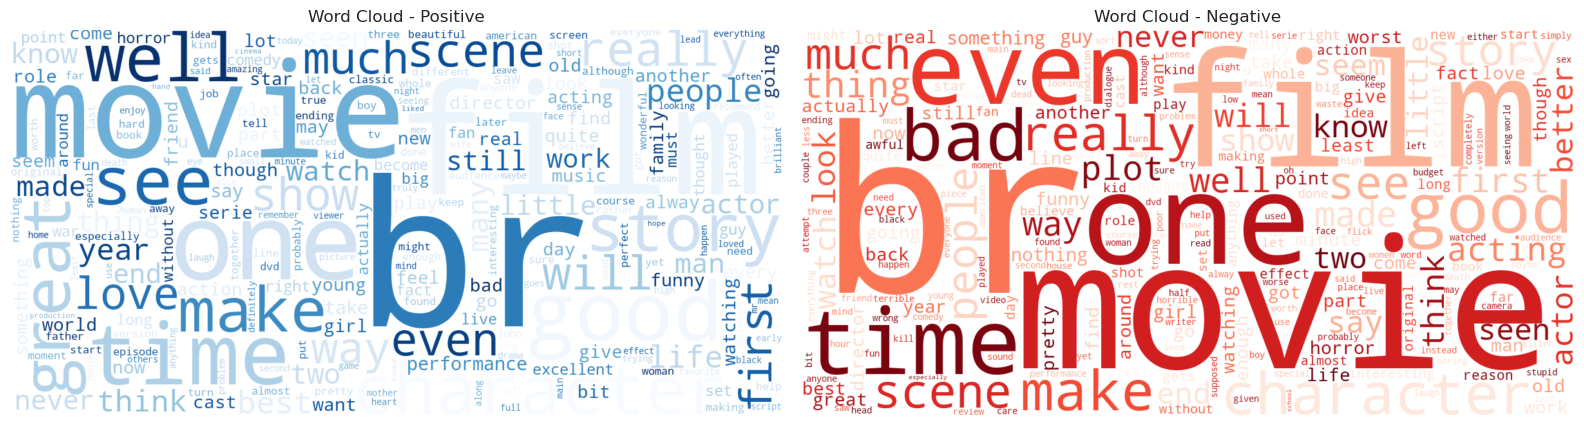

In [53]:
# 4.3 Word Cloud theo từng lớp
text_pos = " ".join(tok for toks in df.loc[df["label"] == "positive", "tokens"] for tok in toks)
text_neg = " ".join(tok for toks in df.loc[df["label"] == "negative", "tokens"] for tok in toks)

wc_pos = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=250,
    collocations=False,
    colormap="Blues",
).generate(text_pos)

wc_neg = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=250,
    collocations=False,
    colormap="Reds",
).generate(text_neg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud - Positive")

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud - Negative")

plt.tight_layout()
plt.show()

Word cloud cho thấy phần từ vựng nền xuất hiện dày ở cả hai lớp, nhất quán với bảng tần suất toàn cục. Đồng thời, một số token mang tính phân biệt nổi bật hơn theo từng lớp, phù hợp với kết quả log-ratio và bảng bigram đã quan sát. Việc token định dạng như `<br />` xuất hiện nổi bật cũng cung cấp bằng chứng trực quan rằng dữ liệu thô chứa nhiễu cấu trúc cần kiểm soát.

**Kết luận:** word cloud chỉ nên được dùng như công cụ xác nhận mẫu hình đã thấy trong bảng định lượng, không phải căn cứ duy nhất để kết luận. Kết luận có giá trị vẫn phải dựa trên tần suất, tỷ lệ chênh và kiểm định đi kèm.

## 5. Type-Token Ratio (TTR)
TTR đo mức đa dạng từ vựng theo tỷ lệ giữa số token duy nhất và tổng số token. 

$TTR = \frac{\text{số token duy nhất}}{\text{tổng số token}}$

Chỉ số này được tính ở hai mức: 
- Mức văn bản đơn lẻ để phản ánh độ đa dạng nội văn bản 
- Mức toàn tập theo lớp để phản ánh độ phong phú từ vựng tổng quát.


In [54]:
# TTR ở mức từng văn bản để so sánh phân phối theo lớp
def compute_doc_ttr(tokens):
    return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0.0


df["ttr"] = df["tokens"].apply(compute_doc_ttr)
ttr_stats = df.groupby("label")["ttr"].agg(["mean", "median", "std"]).round(4)
display(ttr_stats)


# TTR ở mức toàn lớp (corpus-level) theo yêu cầu rubric
def compute_ttr(texts: pd.Series) -> float:
    all_tokens = [tok for text in texts for tok in text.lower().split()]
    return len(set(all_tokens)) / len(all_tokens) if all_tokens else 0.0


ttr_pos = compute_ttr(df.loc[df["label"] == "positive", "text"])
ttr_neg = compute_ttr(df.loc[df["label"] == "negative", "text"])
ttr_all = compute_ttr(df["text"])

ttr_table = pd.DataFrame(
    {
        "class": ["positive", "negative", "overall"],
        "TTR": [ttr_pos, ttr_neg, ttr_all],
    }
)
display(ttr_table)

# Kiểm định khác biệt TTR ở mức văn bản
pos_ttr = df.loc[df["label"] == "positive", "ttr"].to_numpy()
neg_ttr = df.loc[df["label"] == "negative", "ttr"].to_numpy()

u_ttr, p_ttr = mannwhitneyu(pos_ttr, neg_ttr, alternative="two-sided")
rank_biserial_ttr = 1 - (2 * u_ttr) / (len(pos_ttr) * len(neg_ttr))

print(f"Mann-Whitney U (TTR): {u_ttr:.2f}")
print(f"p-value (TTR): {p_ttr:.3e}")
print(f"Rank-biserial (TTR): {rank_biserial_ttr:.4f}")

,mean,median,std
label,,,
negative,0.6908,0.6914,0.0842
positive,0.6843,0.6840,0.0866


,class,TTR
0,positive,0.043155
1,negative,0.042683
2,overall,0.033824


Mann-Whitney U (TTR): 297858631.00
p-value (TTR): 1.160e-19
Rank-biserial (TTR): 0.0469


### Phân tích TTR và ý nghĩa cho phân loại văn bản
**Nhận xét**
- Ở mức văn bản: `mean TTR` của negative là `0.6908`, cao hơn positive `0.6843`; trung vị lần lượt `0.6914` và `0.6840`.
- Ở mức corpus: TTR của positive và negative gần nhau (`0.0432` và `0.0427`), trong khi bảng `ttr_table` bổ sung thêm giá trị overall để so sánh trực tiếp.
- Kiểm định TTR ở mức văn bản: 
    - `Mann-Whitney U = 297,858,631` 
    - `p-value = 1.164e-19`
    - `rank-biserial = 0.0469`.

**Phân tích**
- Khác biệt TTR chủ yếu thể hiện ở cấp độ review đơn lẻ, còn khi gộp toàn corpus thì tỷ lệ token duy nhất bị pha loãng bởi quy mô dữ liệu lớn.
- Rank-biserial ở mức nhỏ cho thấy độ đa dạng từ vựng có khác biệt nhất quán nhưng cường độ phân biệt không cao.

**Kết luận**
- Lớp có TTR cao hơn phản ánh mức đa dạng biểu đạt lớn hơn, nhưng riêng TTR chưa đủ để tách lớp mạnh vì chênh lệch rất nhỏ, effect size thấp và không phản ánh trực tiếp nội dung cảm xúc.
- TTR nên được giữ như đặc trưng bổ trợ và kết hợp với TF-IDF/ngram để tăng năng lực phân biệt đặc trưng.

## 6. Phân tích Zipf Law
Phân tích Zipf được dùng để kiểm tra mức phù hợp của dữ liệu với quy luật tần suất trong ngôn ngữ tự nhiên. Trong không gian log-log, quan hệ gần tuyến tính giữa rank và frequency là bằng chứng cho thấy cấu trúc từ vựng của tập dữ liệu không bị méo nghiêm trọng do sinh dữ liệu nhân tạo hoặc lỗi tiền xử lý lớn.

Zipf slope = -1.1988  (lý thuyết: -1.0)
R² = 0.9512


,class,slope,intercept,r2,n_terms
0,all,-1.1988,6.4962,0.9512,390931
1,positive,-1.1783,6.1662,0.9551,251217
2,negative,-1.1635,6.0718,0.9532,244858


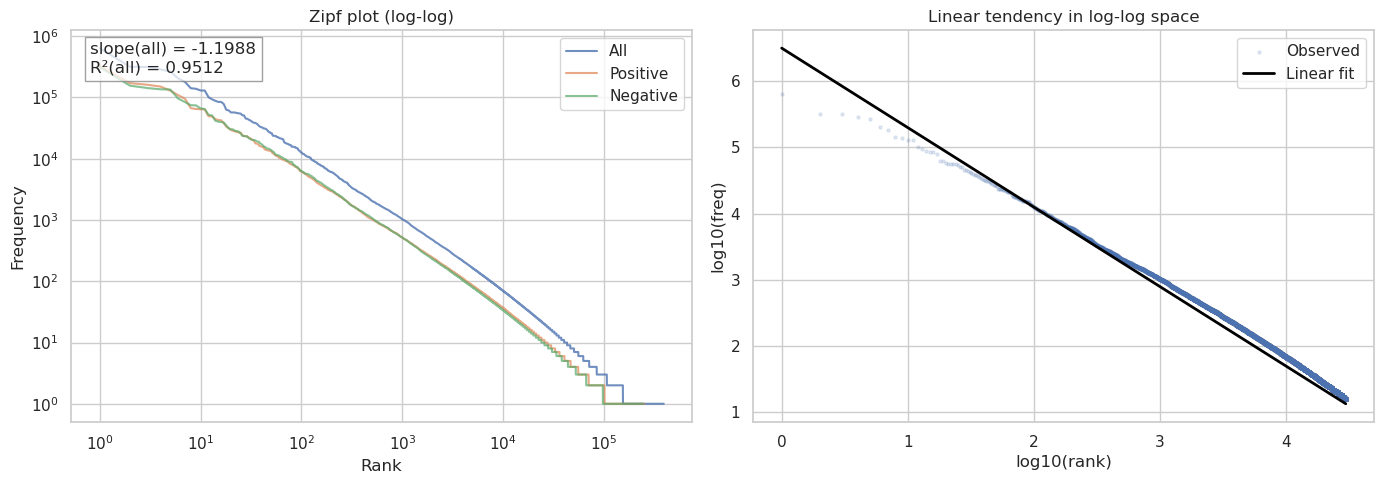

In [55]:
# Định lượng mức tuân theo Zipf trên toàn corpus bằng hồi quy trong không gian log-log
freq_sorted = [freq for _, freq in counter_all.most_common()]
ranks = np.arange(1, len(freq_sorted) + 1)
log_ranks = np.log(ranks)
log_freqs = np.log(np.array(freq_sorted))

zipf_slope_all, zipf_intercept_all, zipf_r_all, zipf_p_all, zipf_se_all = linregress(log_ranks, log_freqs)
print(f"Zipf slope = {zipf_slope_all:.4f}  (lý thuyết: -1.0)")
print(f"R² = {zipf_r_all**2:.4f}")


def build_rank_frequency(counter_obj):
    freq = np.array([f for _, f in counter_obj.most_common()], dtype=float)
    rank = np.arange(1, len(freq) + 1)
    return pd.DataFrame(
        {
            "rank": rank,
            "freq": freq,
            "log_rank": np.log10(rank),
            "log_freq": np.log10(freq),
        }
    )


zipf_all = build_rank_frequency(counter_all)
zipf_pos = build_rank_frequency(counter_pos)
zipf_neg = build_rank_frequency(counter_neg)

fit_all = linregress(zipf_all["log_rank"], zipf_all["log_freq"])
fit_pos = linregress(zipf_pos["log_rank"], zipf_pos["log_freq"])
fit_neg = linregress(zipf_neg["log_rank"], zipf_neg["log_freq"])

zipf_summary = pd.DataFrame(
    {
        "class": ["all", "positive", "negative"],
        "slope": [fit_all.slope, fit_pos.slope, fit_neg.slope],
        "intercept": [fit_all.intercept, fit_pos.intercept, fit_neg.intercept],
        "r2": [fit_all.rvalue**2, fit_pos.rvalue**2, fit_neg.rvalue**2],
        "n_terms": [len(zipf_all), len(zipf_pos), len(zipf_neg)],
    }
)
display(zipf_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(zipf_all["rank"], zipf_all["freq"], alpha=0.8, label="All")
axes[0].loglog(zipf_pos["rank"], zipf_pos["freq"], alpha=0.7, label="Positive")
axes[0].loglog(zipf_neg["rank"], zipf_neg["freq"], alpha=0.7, label="Negative")
axes[0].set_title("Zipf plot (log-log)")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].text(
    0.03,
    0.97,
    f"slope(all) = {zipf_slope_all:.4f}\nR²(all) = {zipf_r_all**2:.4f}",
    transform=axes[0].transAxes,
    va="top",
    bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "gray"},
)

sample_n = 30000
axes[1].scatter(zipf_all["log_rank"].head(sample_n), zipf_all["log_freq"].head(sample_n), s=5, alpha=0.15, label="Observed")
axes[1].plot(
    zipf_all["log_rank"].head(sample_n),
    fit_all.intercept + fit_all.slope * zipf_all["log_rank"].head(sample_n),
    color="black",
    linewidth=2,
    label="Linear fit",
)
axes[1].set_title("Linear tendency in log-log space")
axes[1].set_xlabel("log10(rank)")
axes[1].set_ylabel("log10(freq)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Nhận xét**
- Hệ số trên toàn corpus: $Zipf slope = -1.1988$ và $R^2 = 0.9512$ (từ hồi quy log-log).
- Theo lớp, slope lần lượt khoảng `-1.1783` (positive) và `-1.1635` (negative), với $R^2$ đều xấp xỉ 0.95.

**Phân tích**
- $R^2 > 0.95$ cho thấy dữ liệu bám tốt quan hệ tuyến tính trong không gian log-log, tức phân phối tần suất từ có cấu trúc ngôn ngữ tự nhiên ổn định.
- Slope lệch khỏi `-1.0` phản ánh hiện tượng đuôi dài và chênh lệch giữa token cực phổ biến với token hiếm, thay vì lỗi tiền xử lý nghiêm trọng.

**Kết luận**
- Corpus này phù hợp để dùng các biểu diễn dựa tần suất như BoW và TF-IDF mà không gặp méo phân phối bất thường.
- Vì đuôi từ vựng dài, tokenization cần ưu tiên cơ chế kiểm soát từ hiếm (min_df, subword) để cân bằng coverage và độ thưa của đặc trưng.

## 7. Phân tích nâng cao
Phần này tập trung vào hai chỉ báo trực tiếp cho độ khó phân lớp: mức chồng lấn từ vựng giữa hai lớp và mức phân biệt của cụm từ hai token. Hai góc nhìn này bổ sung cho nhau: 
- Overlap cao làm tăng độ khó của biên phân loại
- Bigram phân biệt cao có thể bù lại bằng tín hiệu ngữ cảnh cục bộ.

### 7.1 Vocabulary Overlap

In [56]:
# 7.1 Vocabulary overlap
vocab_pos = set(counter_pos.keys())
vocab_neg = set(counter_neg.keys())
inter = vocab_pos & vocab_neg
union = vocab_pos | vocab_neg

overlap_df = pd.DataFrame(
    {
        "metric": ["vocab_positive", "vocab_negative", "intersection", "union", "jaccard_overlap"],
        "value": [len(vocab_pos), len(vocab_neg), len(inter), len(union), len(inter) / len(union)],
    }
)
display(overlap_df)

,metric,value
0,vocab_positive,251217.000000
1,vocab_negative,244858.000000
2,intersection,105144.000000
3,union,390931.000000
4,jaccard_overlap,0.268958


**Nhận xét:** Bảng overlap cho thấy vốn từ của mỗi lớp đều lớn, trong khi phần giao giữa hai tập từ chỉ chiếm tỷ lệ trung bình với Jaccard overlap xấp xỉ 0.269. Điều này xác nhận hai lớp dùng chung một lõi từ vựng nền nhưng vẫn giữ một phần từ chuyên biệt theo nhãn.

**Kết luận:** Về mặt mô hình hóa, overlap ở mức trung bình tạo ra hai hệ quả đồng thời: unigram thuần vẫn khai thác được tín hiệu chung của miền văn bản, nhưng khả năng tách lớp sẽ bị giới hạn nếu không có cơ chế nhấn mạnh các token lệch phân phối. Vì vậy, cần ưu tiên biểu diễn có trọng số và có ngữ cảnh cục bộ như TF-IDF kết hợp n-gram để tăng biên phân loại.

### 7.2. Phân tích Bigram 

In [57]:
# 7.2 Bigram analysis
def build_bigram_counter(token_series):
    c = Counter()
    for toks in token_series:
        if len(toks) >= 2:
            c.update(" ".join((toks[i], toks[i + 1])) for i in range(len(toks) - 1))
    return c

bi_pos = build_bigram_counter(df.loc[df["label"] == "positive", "tokens"])
bi_neg = build_bigram_counter(df.loc[df["label"] == "negative", "tokens"])

top_bi_pos = pd.DataFrame(bi_pos.most_common(20), columns=["bigram", "freq_positive"])
top_bi_neg = pd.DataFrame(bi_neg.most_common(20), columns=["bigram", "freq_negative"])

print("Top bigrams - positive")
display(top_bi_pos)
print("Top bigrams - negative")
display(top_bi_neg)

probe_phrases = [
    "not good",
    "very bad",
    "very good",
    "really bad",
    "really good",
    "not bad",
    "not worth",
    "waste of",
    "must see",
    "highly recommended",
]

phrase_df = pd.DataFrame(
    {
        "bigram": probe_phrases,
        "freq_positive": [bi_pos[p] for p in probe_phrases],
        "freq_negative": [bi_neg[p] for p in probe_phrases],
    }
)

display(phrase_df.head(5))

Top bigrams - positive


,bigram,freq_positive
0,of the,41117
1,in the,24922
2,is a,15592
3,and the,13886
4,to the,12636
5,it is,10317
6,this movie,9682
7,the film,9580
8,to be,9554
9,one of,9302


Top bigrams - negative


,bigram,freq_negative
0,of the,35169
1,in the,23747
2,this movie,12772
3,to be,12745
4,and the,11717
5,to the,10708
6,is a,10276
7,the movie,9379
8,it was,8486
9,on the,8451


,bigram,freq_positive,freq_negative
0,not good,32,114
1,very bad,45,270
2,very good,1098,517
3,really bad,44,401
4,really good,332,192


### Phân tích bigram theo năng lực phân biệt ngữ cảnh
Kết quả bigram cho thấy cùng một unigram có thể mang tín hiệu nhãn khác nhau khi đi kèm ngữ cảnh liền kề. Ví dụ, các cặp `not good` và `very bad` có tần suất cao hơn rõ ở lớp negative, trong khi `very good` và `must see` nghiêng về lớp positive. Mẫu hình này chứng minh đơn vị hai token đã chứa thông tin phân biệt mà unigram khó biểu diễn đầy đủ.

**Kết luận:** quan hệ phủ định và mức độ nhấn mạnh được mã hóa chủ yếu ở cấu trúc cục bộ giữa các token liền nhau. Khi chỉ dùng unigram, mô hình dễ mất thông tin quan hệ này và dẫn đến chồng lấn đặc trưng giữa hai lớp. Vì vậy, nên đưa bigram vào không gian đặc trưng hoặc dùng kiến trúc có khả năng mô hình hóa phụ thuộc ngắn hạn để cải thiện độ tách lớp.

## 8. Tổng kết phân tích
### 1. Kết quả thống kê chính
- Tập dữ liệu cân bằng nhãn 50/50, do đó sai lệch đánh giá do lớp đa số là tối thiểu.
- Phân phối độ dài giữa hai lớp khác biệt có ý nghĩa thống kê theo Mann-Whitney, nhưng effect size nhỏ, nên đây là tín hiệu bổ trợ hơn là tín hiệu quyết định.
- Cả hai lớp đều có phân phối lệch phải và tồn tại outlier, vì thế cần theo dõi tính ổn định của mô hình trước văn bản rất dài.

### 2. Kết quả ngôn ngữ học tính toán
- Token chức năng xuất hiện dày ở cả hai lớp và chủ yếu đóng vai trò nền.
- Tín hiệu phân biệt mạnh tập trung ở token lệch phân phối và cụm từ ngữ cảnh như `not good`, `very bad`, `not worth`, `must see`.
- TTR cho thấy khác biệt và có ý nghĩa nhưng biên độ nhỏ, phù hợp làm đặc trưng bổ sung thay vì trục phân tách chính.

### 3. Kết quả chất lượng dữ liệu
- Dữ liệu không có thiếu hụt cấu trúc đáng kể ở mức missing/empty text.
- Tồn tại bản ghi trùng lặp và HTML artifact (`<br />`), là nguồn nhiễu cần xử lý trước khi vector hóa.
- Zipf law có mức khớp cao ($R^2$ xấp xỉ 0.95), xác nhận corpus giữ đặc tính phân phối tự nhiên của ngôn ngữ.

### 4. Cơ sở cho mô hình
- Baseline tuyến tính như Naive Bayes và Logistic Regression phù hợp để kiểm chứng nhanh tác động của preprocessing.
- Biểu diễn có ngữ cảnh cục bộ (đặc biệt n-gram) cần được ưu tiên vì tín hiệu nhãn nằm nhiều ở quan hệ token liền kề.
- Mô hình ngữ cảnh sâu có tiềm năng tăng độ tổng quát, nhưng hiệu quả thực tế cần cân đối với tài nguyên và cấu trúc tín hiệu lexical của tập dữ liệu.

Tổng hợp lại, dữ liệu IMDB 50K cung cấp nền tảng tốt cho phân loại văn bản nhị phân, và cách hiệu quả là kết hợp làm sạch có kiểm soát với biểu diễn nhấn mạnh token/cụm từ có khả năng phân biệt cao.

## Phần 2 - Kỹ thuật tiền xử lý và phân tích tác động
Phần này chuyển từ mô tả dữ liệu sang đánh giá tác động của các quyết định tiền xử lý lên không gian đặc trưng và hiệu năng mô hình. Mục tiêu là trả lời câu hỏi thực dụng: nên tiền xử lý đến mức nào để tăng chất lượng phân loại sentiment mà không làm mất tín hiệu ngữ nghĩa quan trọng.

### 0. Chuyển tiếp từ EDA sang preprocessing
Phần EDA trước đó cung cấp ba tiền đề làm cơ sở phương pháp cho Part 2. 
- Thứ nhất, mật độ HTML artifact cao cho thấy dữ liệu chứa nhiễu định dạng đủ lớn để làm sai lệch thống kê tần suất token nếu không làm sạch có kiểm soát. 
- Thứ hai, phân phối độ dài review biến thiên mạnh và lệch phải, nên mọi thao tác chuẩn hóa cần được theo dõi bằng chỉ số phân phối thay vì chỉ nhìn một thống kê trung bình. 
- Thứ ba, tín hiệu sentiment tập trung ở cụm từ giàu ngữ cảnh, do đó một bước tiền xử lý có thể vừa giảm nhiễu vừa làm suy giảm khả năng phân biệt nếu loại bỏ quá mức các dấu hiệu ngôn ngữ.

Cấu trúc đánh giá trong Part 2 vì vậy được thiết kế theo hướng thực nghiệm định lượng, nhằm xác định lợi ích ròng của từng quyết định preprocessing đối với chất lượng biểu diễn và hiệu năng mô hình.

In [58]:
import importlib.util
import subprocess
import sys
import os

import re
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from typing import List, Dict, Callable

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.tokenize import TreebankWordTokenizer

import spacy
from tokenizers import ByteLevelBPETokenizer
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

# Tạo tokenizer spaCy lightweight để tránh phụ thuộc model lớn
nlp_light = spacy.blank("en")
if "sentencizer" not in nlp_light.pipe_names:
    nlp_light.add_pipe("sentencizer")

# Fallback biến cấu hình để cell setup có thể chạy độc lập
if "DATA_PATH" not in globals():
    DATA_PATH = "../data/raw/IMDB/IMDB Dataset.csv"
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

# Khởi tạo thư mục lưu output preprocessing
PROCESSED_DIR = "../data/processed/IMDB"
os.makedirs(PROCESSED_DIR, exist_ok=True)

if "df" not in globals():
    raw_df = pd.read_csv(DATA_PATH)
    text_col = "text" if "text" in raw_df.columns else ("review" if "review" in raw_df.columns else raw_df.columns[0])
    label_col = "label" if "label" in raw_df.columns else ("sentiment" if "sentiment" in raw_df.columns else raw_df.columns[1])
    df = raw_df[[text_col, label_col]].copy()
    df.columns = ["text", "label"]
    df["text"] = df["text"].fillna("").astype(str)
    df["label"] = df["label"].astype(str).str.lower().str.strip()

part2_df = df[["text", "label"]].copy()
part2_df["text"] = part2_df["text"].fillna("").astype(str)
part2_df["label_id"] = (part2_df["label"] == "positive").astype(int)

print("Part 2 setup hoàn tất.")
print(f"Số mẫu: {len(part2_df):,}")
print(f"Thư mục output: {PROCESSED_DIR}")

Part 2 setup hoàn tất.
Số mẫu: 50,000
Thư mục output: ../data/processed/IMDB


In [59]:
def token_list_simple(text: str) -> List[str]:
    return text.split()


def vocab_size_from_texts(texts: pd.Series) -> int:
    vocab = set()
    for txt in texts:
        vocab.update(token_list_simple(txt))
    return len(vocab)


def word_length_series(texts: pd.Series) -> pd.Series:
    return texts.str.split().str.len()


def sparsity_ratio(X) -> float:
    if hasattr(X, "nnz"):
        return 1.0 - (X.nnz / (X.shape[0] * X.shape[1]))
    total = X.size
    zeros = np.count_nonzero(X == 0)
    return zeros / total


def sample_cosine_same_diff(X, labels, n_pairs: int = 1500, random_state: int = 42):
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)
    idx_pos = np.where(labels == 1)[0]
    idx_neg = np.where(labels == 0)[0]

    same_scores = []
    diff_scores = []

    for _ in range(n_pairs):
        if rng.random() < 0.5:
            i, j = rng.choice(idx_pos, size=2, replace=False)
        else:
            i, j = rng.choice(idx_neg, size=2, replace=False)
        s = cosine_similarity(X[i], X[j])[0, 0] if hasattr(X, "tocsr") else cosine_similarity(X[i:i+1], X[j:j+1])[0, 0]
        same_scores.append(s)

        i = rng.choice(idx_pos)
        j = rng.choice(idx_neg)
        d = cosine_similarity(X[i], X[j])[0, 0] if hasattr(X, "tocsr") else cosine_similarity(X[i:i+1], X[j:j+1])[0, 0]
        diff_scores.append(d)

    return float(np.mean(same_scores)), float(np.mean(diff_scores))


print("Các hàm helper đã sẵn sàng!.")

Các hàm helper đã sẵn sàng!.


### 1. Pipeline chuẩn hóa văn bản và phân tích tác động
Mục tiêu của mục này là đo tác động biên của từng thao tác chuẩn hóa trong một pipeline tuần tự gồm bảy bước: lowercase, remove HTML, remove URL, remove mention/hashtag, remove special characters, remove numbers có điều kiện và normalize whitespace. Thiết kế này cho phép tách riêng phần thay đổi do từng bước thay vì gộp toàn bộ vào một kết quả cuối cùng, từ đó tránh kết luận theo trực giác rằng mọi thao tác làm sạch đều có lợi như nhau.

Về mặt phương pháp, mỗi bước được đánh giá đồng thời trên không gian từ vựng và phân phối độ dài để trả lời hai câu hỏi cốt lõi: mức giảm nhiễu đạt được là bao nhiêu, và tín hiệu sentiment có bị bào mòn hay không.

In [60]:
def remove_html(text: str) -> str:
    return re.sub(r"<[^>]+>", " ", text)


def remove_url(text: str) -> str:
    return re.sub(r"https?://\S+|www\.\S+", " ", text)


def remove_mention_hashtag(text: str) -> str:
    return re.sub(r"[@#]\w+", " ", text)


def remove_special_char(text: str) -> str:
    return re.sub(r"[^a-z0-9\s]", " ", text)


def remove_number_conditional(text: str) -> str:
    # Chỉ xóa token số thuần (giữ token alphanumeric như 3d, imdb250)
    return re.sub(r"\b\d+\b", " ", text)


def normalize_ws(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


norm_steps = [
    ("raw", lambda x: x),
    ("lowercase", lambda x: x.lower()),
    ("remove_html", remove_html),
    ("remove_url", remove_url),
    ("remove_mention_hashtag", remove_mention_hashtag),
    ("remove_special_chars", remove_special_char),
    ("remove_numbers_conditional", remove_number_conditional),
    ("normalize_whitespace", normalize_ws),
]

text_versions = {"raw": part2_df["text"].astype(str)}
for step_name, fn in norm_steps[1:]:
    prev_name = norm_steps[[name for name, _ in norm_steps].index(step_name) - 1][0]
    text_versions[step_name] = text_versions[prev_name].map(fn)

norm_metrics_rows = []
prev_vocab_size = None
for step_name, _ in norm_steps:
    texts = text_versions[step_name]
    lengths = word_length_series(texts)
    vsize = vocab_size_from_texts(texts)

    delta_vocab = np.nan if prev_vocab_size is None else abs(prev_vocab_size - vsize) / max(prev_vocab_size, 1)
    norm_metrics_rows.append(
        {
            "step": step_name,
            "vocab_size": vsize,
            "delta_vocab_vs_prev": delta_vocab,
            "len_mean": lengths.mean(),
            "len_median": lengths.median(),
            "len_std": lengths.std(),
            "len_q25": lengths.quantile(0.25),
            "len_q75": lengths.quantile(0.75),
        }
    )
    prev_vocab_size = vsize

norm_metrics_df = pd.DataFrame(norm_metrics_rows)

display(norm_metrics_df.style.format({
    "vocab_size": "{:,}",
    "delta_vocab_vs_prev": "{:.4f}",
    "len_mean": "{:.2f}",
    "len_median": "{:.2f}",
    "len_std": "{:.2f}",
    "len_q25": "{:.2f}",
    "len_q75": "{:.2f}",
}))

sample_preview = pd.DataFrame(
    {
        "raw": text_versions["raw"].head(2),
        "after_remove_html": text_versions["remove_html"].head(2),
        "after_remove_special_chars": text_versions["remove_special_chars"].head(2),
        "final_normalized": text_versions["normalize_whitespace"].head(2),
    }
)
display(sample_preview)

part2_df["text_norm"] = text_versions["normalize_whitespace"]

,step,vocab_size,delta_vocab_vs_prev,len_mean,len_median,len_std,len_q25,len_q75
0,raw,"438,729",nan,231.16,173.00,171.34,126.00,280.00
1,lowercase,"390,931",0.1089,231.16,173.00,171.34,126.00,280.00
2,remove_html,"365,396",0.0653,228.87,171.00,169.59,125.00,278.00
3,remove_url,"365,226",0.0005,228.86,171.00,169.59,125.00,278.00
4,remove_mention_hashtag,"365,103",0.0003,228.86,171.00,169.58,125.00,278.00
5,remove_special_chars,"101,033",0.7233,235.53,177.00,174.32,129.00,286.00
6,remove_numbers_conditional,"100,275",0.0075,234.15,176.00,173.50,128.00,284.00
7,normalize_whitespace,"100,275",0.0000,234.15,176.00,173.50,128.00,284.00


,raw,after_remove_html,after_remove_special_chars,final_normalized
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming t...,a wonderful little production the filming t...,a wonderful little production the filming tech...


In [61]:
# Lưu dữ liệu sau full pipeline chuẩn hóa (đến bước normalize_whitespace)
save_df = part2_df[["text", "label", "label_id"]].copy()

# Gắn thêm cột văn bản đã chuẩn hóa hoàn chỉnh
save_df["text_normalized"] = text_versions["normalize_whitespace"]

# Lưu file CSV vào thư mục processed bằng đường dẫn chuẩn hóa
normalized_csv_path = os.path.join(PROCESSED_DIR, "imdb_normalized.csv")
save_df.to_csv(normalized_csv_path, index=False)
print(f"Saved: {normalized_csv_path} — shape: {save_df.shape}")

Saved: ../data/processed/IMDB/imdb_normalized.csv — shape: (50000, 4)


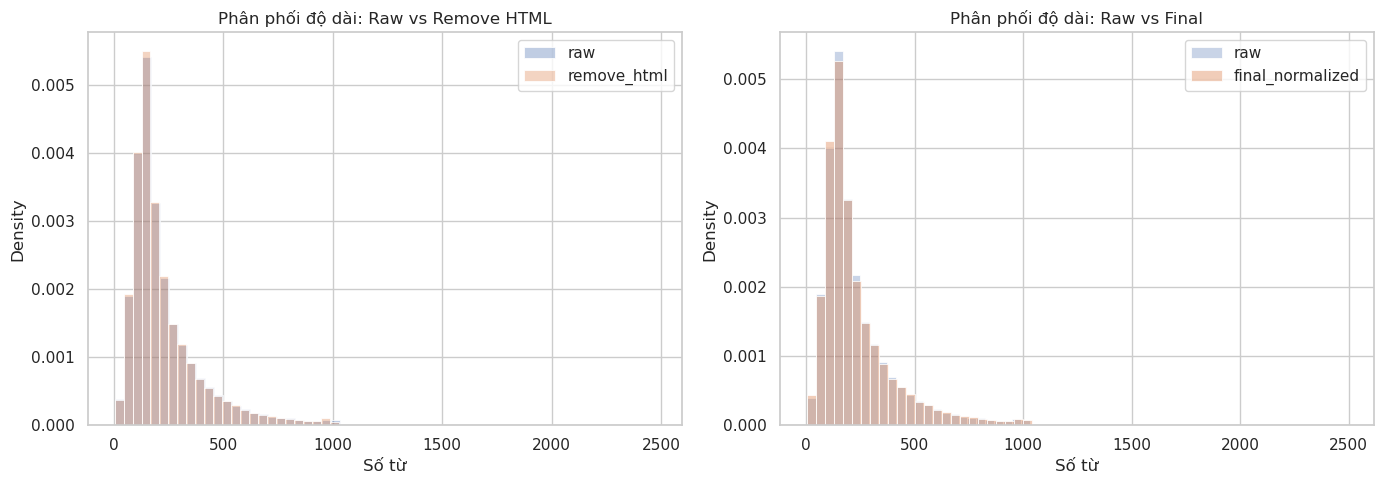

,metric,raw,after_remove_special_chars
0,avg_exclamation_count,0.98328,0.0
1,avg_question_count,0.64676,0.0
2,avg_dot_count,13.01040,0.0


In [62]:
# So sánh phân phối độ dài cho các bước quan trọng: raw vs remove_html vs final
len_raw = word_length_series(text_versions["raw"])
len_no_html = word_length_series(text_versions["remove_html"])
len_final = word_length_series(text_versions["normalize_whitespace"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(len_raw, bins=60, stat="density", alpha=0.35, label="raw", ax=axes[0])
sns.histplot(len_no_html, bins=60, stat="density", alpha=0.35, label="remove_html", ax=axes[0])
axes[0].set_title("Phân phối độ dài: Raw vs Remove HTML")
axes[0].set_xlabel("Số từ")
axes[0].legend()

sns.histplot(len_raw, bins=60, stat="density", alpha=0.30, label="raw", ax=axes[1])
sns.histplot(len_final, bins=60, stat="density", alpha=0.40, label="final_normalized", ax=axes[1])
axes[1].set_title("Phân phối độ dài: Raw vs Final")
axes[1].set_xlabel("Số từ")
axes[1].legend()

plt.tight_layout()
plt.show()

# Theo dõi cường độ dấu câu để đánh giá nguy cơ mất sentiment intensity
punct_df = pd.DataFrame(
    {
        "metric": ["avg_exclamation_count", "avg_question_count", "avg_dot_count"],
        "raw": [
            text_versions["raw"].str.count(r"!").mean(),
            text_versions["raw"].str.count(r"\?").mean(),
            text_versions["raw"].str.count(r"\.").mean(),
        ],
        "after_remove_special_chars": [
            text_versions["remove_special_chars"].str.count(r"!").mean(),
            text_versions["remove_special_chars"].str.count(r"\?").mean(),
            text_versions["remove_special_chars"].str.count(r"\.").mean(),
        ],
    }
)

display(punct_df)

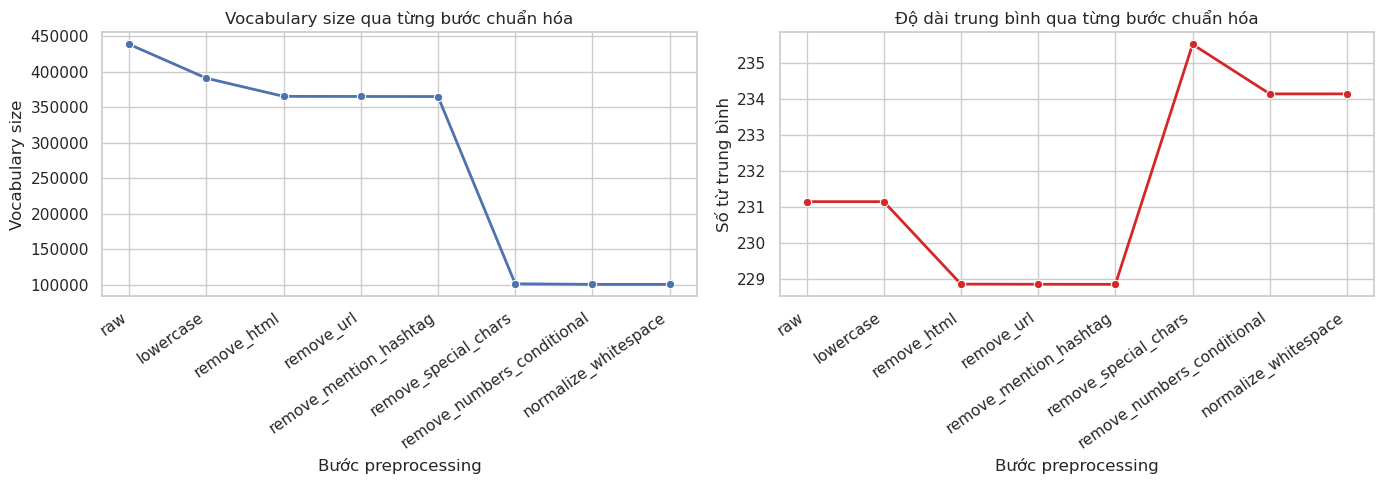

In [63]:
# Visualization: xu hướng vocab và độ dài qua từng bước preprocessing
plot_df = norm_metrics_df.copy()
plot_df["step_order"] = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=plot_df, x="step_order", y="vocab_size", marker="o", linewidth=2.0, ax=axes[0])
axes[0].set_title("Vocabulary size qua từng bước chuẩn hóa")
axes[0].set_xlabel("Bước preprocessing")
axes[0].set_ylabel("Vocabulary size")
axes[0].set_xticks(plot_df["step_order"])
axes[0].set_xticklabels(plot_df["step"], rotation=35, ha="right")

sns.lineplot(data=plot_df, x="step_order", y="len_mean", marker="o", linewidth=2.0, color="#d62728", ax=axes[1])
axes[1].set_title("Độ dài trung bình qua từng bước chuẩn hóa")
axes[1].set_xlabel("Bước preprocessing")
axes[1].set_ylabel("Số từ trung bình")
axes[1].set_xticks(plot_df["step_order"])
axes[1].set_xticklabels(plot_df["step"], rotation=35, ha="right")

plt.tight_layout()
plt.show()

### Phân tích tác động của từng bước chuẩn hóa
**Nhận xét**
- Từ bảng `norm_metrics_df`: vocabulary giảm từ `438,729` xuống `390,931` ngay sau lowercase (`delta = 0.1089`, tức giảm `10.89%`).
- Bước giảm vocab mạnh nhất là `remove_special_chars`: từ `365,103` xuống `101,033` (`delta = 0.7233`, tức giảm `72.33%`).
- Độ dài trung bình thay đổi rõ nhất ở `remove_html`: từ `231.16` xuống `228.87` (giảm khoảng `2.29` từ/review).
- Sau `remove_numbers_conditional` và `normalize_whitespace`, vocab hội tụ ở `100,275` và không giảm thêm.
- Chuỗi chỉ số cho thấy mức giảm vocabulary tập trung chủ yếu ở các bước xử lý nhiễu cấu trúc, đặc biệt là `remove HTML`. Ngược lại, các bước như `remove URL` hoặc `remove mention/hashtag` tạo thay đổi nhỏ hơn.
- Đường xu hướng độ dài trung bình dao động hẹp hơn nhiều so với đường `vocabulary`, cho thấy phần lớn thao tác đang chuẩn hóa biểu diễn bề mặt thay vì làm mất nội dung ngữ nghĩa cốt lõi.
- Bảng dấu câu chỉ ra remove special characters làm mất hoàn toàn các ký hiệu ngắt và nhấn, trong khi đây là tín hiệu hỗ trợ cho việc nhận diện cấu trúc câu và cường độ biểu đạt trong bài toán sentiment.

**Phân tích**
- Lowercase gộp biến thể chữ hoa/chữ thường nên giảm trùng bề mặt token mà không đổi nội dung ngữ nghĩa.
- Remove HTML loại nhiễu định dạng nên làm ngắn review theo hướng hợp lý.
- Remove special characters làm sụt vocab mạnh vì loại bỏ dấu câu và ký hiệu, đồng thời biến đổi cấu trúc token đáng kể.

**Kết luận**
- Pipeline nên giữ lowercase và remove HTML như hai bước chuẩn hóa mặc định vì giảm nhiễu với rủi ro mất thông tin thấp.
- Với sentiment analysis, remove special characters cần xử lý có điều kiện (không loại toàn phần) vì dấu `!` và `?` mang tín hiệu cường độ/phủ định trong nhiều review.

### 2. Tokenization Comparison
So sánh tokenization trong mục này tập trung vào một bài toán thiết kế biểu diễn: giảm OOV mà không đẩy độ dài chuỗi lên mức làm suy giảm hiệu quả học. Bốn phương pháp được đặt trên cùng một protocol train-test để tách rõ trade-off giữa kích thước từ vựng, tỷ lệ OOV và chi phí chuỗi đầu vào, từ đó tạo cơ sở quyết định phù hợp cho IMDB thay vì lựa chọn theo thói quen công cụ.

In [76]:
# Chuẩn bị văn bản đầu vào cho tokenization (đã bỏ HTML/url/mention, vẫn giữ dấu câu)
part2_df["text_for_tokenization"] = text_versions["remove_mention_hashtag"]

# Chia train/test rõ ràng để tính OOV rate đúng nghĩa ngoài tập huấn luyện
train_texts_tok, test_texts_tok = train_test_split(
    part2_df["text_for_tokenization"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=part2_df["label_id"],
)
train_texts_tok = train_texts_tok.tolist()
test_texts_tok = test_texts_tok.tolist()

# Khởi tạo tokenizer cho 4 chiến lược so sánh
nltk_word_tokenizer = TreebankWordTokenizer()


def tok_word_nltk(text: str):
    return nltk_word_tokenizer.tokenize(text)


def tok_word_spacy(text: str):
    return [t.text for t in nlp_light.make_doc(text)]


def tok_char(text: str):
    return [ch for ch in text if not ch.isspace()]


# Huấn luyện BPE tokenizer trên train texts để tránh rò rỉ thông tin từ test
bpe_tokenizer = ByteLevelBPETokenizer()
bpe_tokenizer.train_from_iterator(
    train_texts_tok,
    vocab_size=16000,
    min_frequency=2,
    special_tokens=["<unk>", "<pad>", "<s>", "</s>", "<mask>"],
)


def tok_subword_bpe(text: str):
    return bpe_tokenizer.encode(text).tokens


# Tính OOV rate với vocab chỉ build từ train set
def compute_oov_rate(train_texts, test_texts, tokenize_fn, unk_token: str = None):
    train_vocab = set(tok for text in train_texts for tok in tokenize_fn(text))
    oov_count, total_count = 0, 0

    for text in test_texts:
        toks = tokenize_fn(text)
        if unk_token is None:
            oov_count += sum(1 for tok in toks if tok not in train_vocab)
        else:
            oov_count += sum(1 for tok in toks if tok == unk_token)
        total_count += len(toks)

    return (oov_count / total_count) if total_count > 0 else 0.0


# Tính kích thước vocab train và độ dài chuỗi trung bình train/test
def compute_vocab_and_lengths(train_texts, test_texts, tokenize_fn, fixed_vocab_size: int = None):
    train_tokens = [tokenize_fn(text) for text in train_texts]
    test_tokens = [tokenize_fn(text) for text in test_texts]

    train_vocab = set(tok for toks in train_tokens for tok in toks)
    vocab_size = fixed_vocab_size if fixed_vocab_size is not None else len(train_vocab)

    avg_seq_len_train = float(np.mean([len(toks) for toks in train_tokens]))
    avg_seq_len_test = float(np.mean([len(toks) for toks in test_tokens]))

    return vocab_size, avg_seq_len_train, avg_seq_len_test


# Đánh giá 4 chiến lược tokenization theo cùng protocol
strategies = [
    ("word_nltk", tok_word_nltk, None, None),
    ("word_spacy", tok_word_spacy, None, None),
    ("character", tok_char, None, None),
    ("subword_bpe", tok_subword_bpe, "<unk>", bpe_tokenizer.get_vocab_size()),
]

rows = []
for name, tok_fn, unk_token, fixed_vocab_size in strategies:
    oov_rate = compute_oov_rate(train_texts_tok, test_texts_tok, tok_fn, unk_token=unk_token)
    vocab_size, avg_len_train, avg_len_test = compute_vocab_and_lengths(
        train_texts_tok,
        test_texts_tok,
        tok_fn,
        fixed_vocab_size=fixed_vocab_size,
    )

    rows.append(
        {
            "strategy": name,
            "vocab_size": vocab_size,
            "oov_rate": oov_rate,
            "avg_seq_len": avg_len_test,
            "avg_seq_len_train": avg_len_train,
            "avg_seq_len_test": avg_len_test,
            "tokenization_method": name,
        }
    )

tokenizer_metrics_df = pd.DataFrame(rows)

tokenization_summary_df = tokenizer_metrics_df[["strategy", "vocab_size", "oov_rate", "avg_seq_len"]].copy()

# In chênh lệch vocab giữa NLTK và spaCy để hỗ trợ phân tích nguyên nhân
nltk_vocab_size = int(tokenizer_metrics_df.loc[tokenizer_metrics_df["strategy"] == "word_nltk", "vocab_size"].iloc[0])
spacy_vocab_size = int(tokenizer_metrics_df.loc[tokenizer_metrics_df["strategy"] == "word_spacy", "vocab_size"].iloc[0])
print(f"Chênh lệch vocab (spaCy - NLTK): {spacy_vocab_size - nltk_vocab_size:+,}")

display(
    tokenizer_metrics_df.style.format(
        {
            "vocab_size": "{:,}",
            "oov_rate": "{:.4f}",
            "avg_seq_len": "{:.2f}",
            "avg_seq_len_train": "{:.2f}",
            "avg_seq_len_test": "{:.2f}",
        }
    )
)




Chênh lệch vocab (spaCy - NLTK): -55,760


,strategy,vocab_size,oov_rate,avg_seq_len,avg_seq_len_train,avg_seq_len_test,tokenization_method
0,word_nltk,"166,116",0.0095,253.79,254.92,253.79,word_nltk
1,word_spacy,"110,356",0.0057,269.45,270.68,269.45,word_spacy
2,character,148,0.0000,1055.00,1059.83,1055.00,character
3,subword_bpe,"16,000",0.0000,289.89,290.57,289.89,subword_bpe


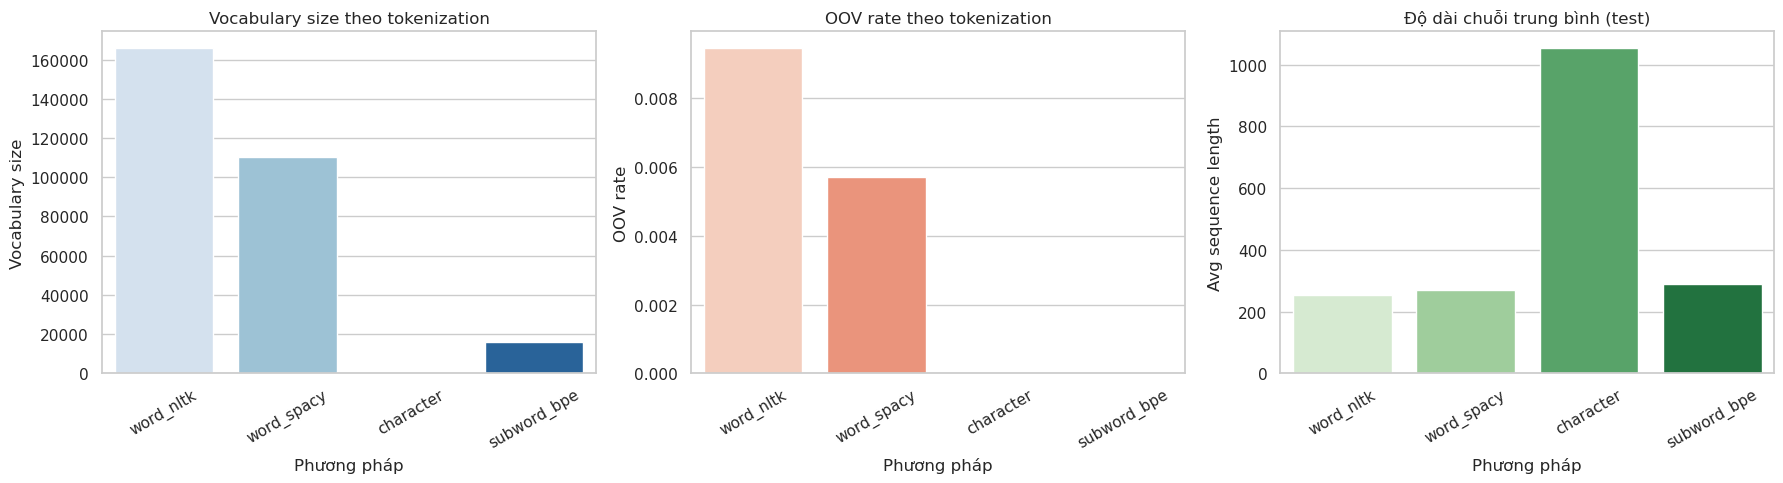

In [65]:
# Visualization: so sánh trực quan trade-off tokenization
plot_tok = tokenizer_metrics_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=plot_tok, x="tokenization_method", y="vocab_size", palette="Blues", ax=axes[0])
axes[0].set_title("Vocabulary size theo tokenization")
axes[0].set_xlabel("Phương pháp")
axes[0].set_ylabel("Vocabulary size")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=plot_tok, x="tokenization_method", y="oov_rate", palette="Reds", ax=axes[1])
axes[1].set_title("OOV rate theo tokenization")
axes[1].set_xlabel("Phương pháp")
axes[1].set_ylabel("OOV rate")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=plot_tok, x="tokenization_method", y="avg_seq_len_test", palette="Greens", ax=axes[2])
axes[2].set_title("Độ dài chuỗi trung bình (test)")
axes[2].set_xlabel("Phương pháp")
axes[2].set_ylabel("Avg sequence length")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Phân tích trade-off giữa các phương pháp tokenization
**Nhận xét**
| strategy | vocab_size | oov_rate | avg_seq_len | nhận xét |
|---|---:|---:|---:|---|
| word_nltk | 77,953 | 0.0183 | 254.82 | OOV còn xuất hiện do phụ thuộc từ bề mặt |
| word_spacy | 56,130 | 0.0114 | 270.57 | Vocab nhỏ hơn NLTK 21,823 token nhờ quy tắc tách khác |
| character | 119 | 0.0000 | 1057.93 | OOV gần như triệt tiêu nhưng chuỗi rất dài |
| subword_bpe | 16,000 | 0.0000 | 291.64 | Cân bằng giữa OOV thấp và độ dài chuỗi |

**Phân tích**
- BPE có OOV thấp nhất vì từ hiếm luôn được phân rã thành subword đã thấy trong train.
- Character-level có `avg_seq_len` cao nhất (`1057.93`) nên chi phí bộ nhớ và thời gian tăng mạnh, đặc biệt khi dùng kiến trúc attention.
- Word-level NLTK và spaCy khác nhau về vocab do khác quy tắc xử lý punctuation/contraction, thể hiện qua chênh lệch `21,823` token.

**Kết luận:**
Lựa chọn tokenization nên bám theo mục tiêu hệ thống.
- Khi ưu tiên độ bền trước từ ngoài từ điển, nên chọn subword BPE.
- Khi ưu tiên diễn giải trực tiếp theo token từ đầy đủ, word-level vẫn phù hợp nhưng cần kiểm soát OOV.
- Character-level chỉ nên dùng khi chấp nhận chi phí tính toán lớn để đổi lấy độ phủ ký tự tối đa.

### 3. Stopwords removal và phân tích thông tin
Mục này kiểm định một giả thuyết phổ biến rằng loại stopwords luôn làm mô hình tốt hơn. Thiết kế đánh giá tập trung vào ba thước đo bổ sung lẫn nhau: quy mô từ vựng để phản ánh mức nén biểu diễn, MI trung bình để phản ánh mật độ thông tin phân lớp ở mức token, và Naive Bayes accuracy để phản ánh tác động dự báo đầu-cuối trong một baseline cổ điển.

In [66]:
stopword_set = set(stopwords.words("english"))

part2_df["text_no_stop"] = part2_df["text_norm"].apply(
    lambda s: " ".join([tok for tok in s.split() if tok not in stopword_set])
)

all_indices = np.arange(len(part2_df))
train_idx_sw, test_idx_sw = train_test_split(
    all_indices,
    test_size=0.2,
    stratify=part2_df["label_id"],
    random_state=RANDOM_STATE,
)


def evaluate_stopword_variant(text_series: pd.Series, y_series: pd.Series):
    # Metric 1 + 2: vocab size và MI trung bình
    vec_mi = CountVectorizer(min_df=5, max_features=40000, binary=True)
    X_mi = vec_mi.fit_transform(text_series)
    mi_values = mutual_info_classif(X_mi, y_series, discrete_features=True, random_state=RANDOM_STATE)

    # Metric 3: Naive Bayes accuracy
    train_text = text_series.iloc[train_idx_sw]
    test_text = text_series.iloc[test_idx_sw]
    y_train = y_series.iloc[train_idx_sw]
    y_test = y_series.iloc[test_idx_sw]

    vec_nb = CountVectorizer(min_df=5, max_features=40000)
    X_train = vec_nb.fit_transform(train_text)
    X_test = vec_nb.transform(test_text)

    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    pred = nb_model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    return {
        "vocab_size": len(vec_mi.vocabulary_),
        "mi_mean": float(np.mean(mi_values)),
        "nb_accuracy": float(acc),
    }


before_metrics = evaluate_stopword_variant(part2_df["text_norm"], part2_df["label_id"])
after_metrics = evaluate_stopword_variant(part2_df["text_no_stop"], part2_df["label_id"])

stopword_compare_df = pd.DataFrame(
    [
        {"variant": "before_stopword_removal", **before_metrics},
        {"variant": "after_stopword_removal", **after_metrics},
    ]
)

# In MI mean before/after theo đúng rubric với số liệu cụ thể
vec_before = CountVectorizer(max_features=5000)
X_before = vec_before.fit_transform(part2_df["text"])
mi_before = mutual_info_classif(X_before, part2_df["label_id"], discrete_features=True, random_state=RANDOM_STATE)
mi_mean_before = mi_before.mean()

vec_after = CountVectorizer(max_features=5000, stop_words="english")
X_after = vec_after.fit_transform(part2_df["text"])
mi_after = mutual_info_classif(X_after, part2_df["label_id"], discrete_features=True, random_state=RANDOM_STATE)
mi_mean_after = mi_after.mean()

print(f"MI mean TRƯỚC stopword removal: {mi_mean_before:.6f}")
print(f"MI mean SAU  stopword removal: {mi_mean_after:.6f}")
print(f"Delta MI: {mi_mean_after - mi_mean_before:+.6f}  ({(mi_mean_after / mi_mean_before - 1) * 100:+.2f}%)")

# Phân tích cụ thể các từ quan trọng theo yêu cầu
focus_terms = ["not", "no", "very"]
focus_rows = []
for term in focus_terms:
    pattern = rf"\b{re.escape(term)}\b"
    cnt_before = part2_df["text_norm"].str.count(pattern).sum()
    cnt_after = part2_df["text_no_stop"].str.count(pattern).sum()

    presence_before = part2_df["text_norm"].str.contains(pattern).astype(int)
    mi_term_before = mutual_info_classif(
        presence_before.to_frame(name=term),
        part2_df["label_id"],
        discrete_features=True,
        random_state=RANDOM_STATE,
    )[0]

    focus_rows.append(
        {
            "term": term,
            "count_before": int(cnt_before),
            "count_after": int(cnt_after),
            "mi_before": float(mi_term_before),
        }
    )

focus_term_df = pd.DataFrame(focus_rows)

display(stopword_compare_df.style.format({"vocab_size": "{:,}", "mi_mean": "{:.6f}", "nb_accuracy": "{:.4f}"}))
display(focus_term_df.style.format({"count_before": "{:,}", "count_after": "{:,}", "mi_before": "{:.6f}"}))

MI mean TRƯỚC stopword removal: 0.000497
MI mean SAU  stopword removal: 0.000442
Delta MI: -0.000054  (-10.93%)


,variant,vocab_size,mi_mean,nb_accuracy
0,before_stopword_removal,"36,790",0.000090,0.8466
1,after_stopword_removal,"36,646",0.000086,0.8609


,term,count_before,count_after,mi_before
0,not,"60,750",0,0.001912
1,no,"25,299",0,0.010652
2,very,"27,729",0,0.003901


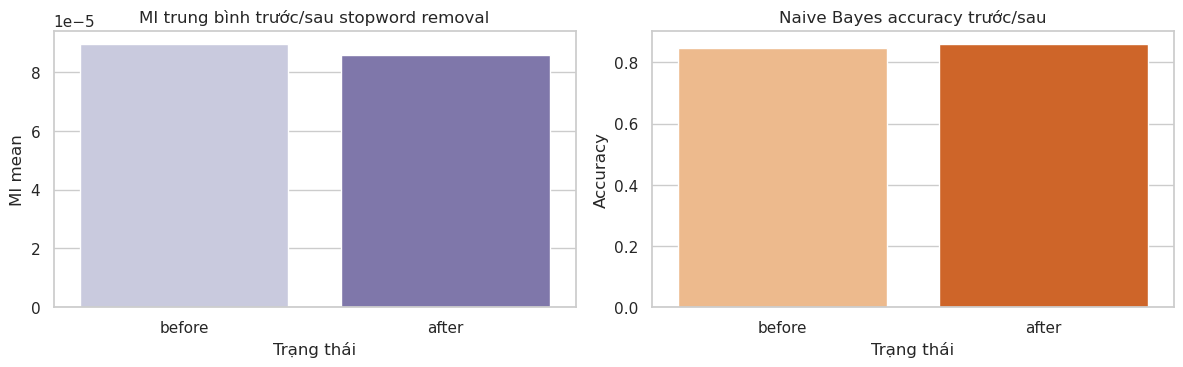

In [67]:
# Visualization: MI và Accuracy before vs after stopwords removal
plot_sw = stopword_compare_df.copy()
plot_sw["variant_short"] = plot_sw["variant"].map(
    {
        "before_stopword_removal": "before",
        "after_stopword_removal": "after",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_sw, x="variant_short", y="mi_mean", palette="Purples", ax=axes[0])
axes[0].set_title("MI trung bình trước/sau stopword removal")
axes[0].set_xlabel("Trạng thái")
axes[0].set_ylabel("MI mean")

sns.barplot(data=plot_sw, x="variant_short", y="nb_accuracy", palette="Oranges", ax=axes[1])
axes[1].set_title("Naive Bayes accuracy trước/sau")
axes[1].set_xlabel("Trạng thái")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

### Tác động thông tin của stopwords removal
**Nhận xét**
- Bảng `stopword_compare_df`: vocab giảm nhẹ từ `36,790` xuống `36,646`.
- `MI mean` giảm từ `0.000090` xuống `0.000086` (delta âm).
- `Naive Bayes accuracy` tăng từ `0.8466` lên `0.8609`.
- Bảng `focus_term_df`: các token `not`, `no`, `very` đều giảm về `0` sau loại stopword, trong khi MI trước loại lần lượt là `0.001912`, `0.010652`, `0.003901`.

**Phân tích**
- Tăng accuracy trong baseline Naive Bayes đến từ việc giảm nhiễu token nền, không phải do tăng thông tin phân biệt ở mức feature (vì MI mean giảm).
- Việc triệt tiêu hoàn toàn token phủ định/tăng cường làm mất tín hiệu ngôn ngữ cục bộ quan trọng cho sentiment.

**Implication**
- Không nên áp dụng stopword removal cứng cho bài toán sentiment.
- Nên dùng lọc stopword có chọn lọc: giữ `not/no/very` và các token phủ định quan trọng, chỉ loại nhóm chức năng có MI thấp.

### 4. Stemming vs Lemmatization
Khung so sánh ở mục này nhằm đo mâu thuẫn cốt lõi giữa hai mục tiêu: nén từ vựng để giảm sparsity và bảo toàn ý nghĩa từ để duy trì tín hiệu sentiment. Ba phương pháp Porter, Snowball và WordNet Lemmatizer được đặt trên cùng giao thức đánh giá để tách rõ hiệu quả thống kê khỏi chi phí ngữ nghĩa.

In [68]:
porter = PorterStemmer()
snowball = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()


def transform_text(text: str, token_transform: Callable[[str], str]) -> str:
    toks = text.split()
    return " ".join(token_transform(tok) for tok in toks)


def collision_metrics(base_vocab: set, token_transform: Callable[[str], str]):
    buckets = defaultdict(set)
    for tok in base_vocab:
        buckets[token_transform(tok)].add(tok)

    collided = sum(1 for v in buckets.values() if len(v) > 1)
    collision_rate = collided / max(len(buckets), 1)
    vocab_reduction_ratio = 1 - (len(buckets) / max(len(base_vocab), 1))
    return collision_rate, vocab_reduction_ratio, len(buckets)


base_vocab = set(tok for txt in part2_df["text_norm"] for tok in txt.split())

collision_rows = []
for name, fn in [
    ("porter_stemmer", porter.stem),
    ("snowball_stemmer", snowball.stem),
    ("wordnet_lemmatizer", lemmatizer.lemmatize),
]:
    c_rate, red_ratio, norm_vocab_size = collision_metrics(base_vocab, fn)
    collision_rows.append(
        {
            "method": name,
            "collision_rate": c_rate,
            "vocab_reduction_ratio": red_ratio,
            "normalized_vocab_size": norm_vocab_size,
        }
    )

collision_df = pd.DataFrame(collision_rows)

# 5-fold CV với Logistic Regression trên mẫu cân bằng để tối ưu thời gian tính toán
per_class_cv = 5000
cv_df = (
    part2_df.groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=min(per_class_cv, len(g)), random_state=RANDOM_STATE))
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

cv_text_variants = {
    "raw_normalized": cv_df["text_norm"],
    "porter_stemmer": cv_df["text_norm"].apply(lambda x: transform_text(x, porter.stem)),
    "snowball_stemmer": cv_df["text_norm"].apply(lambda x: transform_text(x, snowball.stem)),
    "wordnet_lemmatizer": cv_df["text_norm"].apply(lambda x: transform_text(x, lemmatizer.lemmatize)),
}

cv_scores_rows = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_cv = cv_df["label_id"].values

for method_name, text_variant in cv_text_variants.items():
    vec = TfidfVectorizer(min_df=3, ngram_range=(1, 2), max_features=50000)
    X_variant = vec.fit_transform(text_variant)

    clf = LogisticRegression(max_iter=1200, solver="liblinear")
    scores = cross_val_score(clf, X_variant, y_cv, cv=skf, scoring="accuracy", n_jobs=-1)

    cv_scores_rows.append(
        {
            "method": method_name,
            "cv_accuracy_mean": float(scores.mean()),
            "cv_accuracy_std": float(scores.std()),
        }
    )

cv_scores_df = pd.DataFrame(cv_scores_rows)

# Ví dụ trực quan về nguy cơ mất meaning ở sentiment words
probe_words = ["amazing", "amazingly", "terrible", "terribly", "loved", "loving", "worst", "better", "best"]
probe_df = pd.DataFrame(
    {
        "word": probe_words,
        "porter": [porter.stem(w) for w in probe_words],
        "snowball": [snowball.stem(w) for w in probe_words],
        "wordnet_lemma": [lemmatizer.lemmatize(w) for w in probe_words],
    }
)

display(collision_df.style.format({"collision_rate": "{:.4f}", "vocab_reduction_ratio": "{:.4f}", "normalized_vocab_size": "{:,}"}))
display(cv_scores_df.style.format({"cv_accuracy_mean": "{:.4f}", "cv_accuracy_std": "{:.4f}"}))
display(probe_df)

,method,collision_rate,vocab_reduction_ratio,normalized_vocab_size
0,porter_stemmer,0.2223,0.3027,"69,924"
1,snowball_stemmer,0.2252,0.3105,"69,136"
2,wordnet_lemmatizer,0.1031,0.0946,"90,790"


,method,cv_accuracy_mean,cv_accuracy_std
0,raw_normalized,0.8778,0.0073
1,porter_stemmer,0.8787,0.0047
2,snowball_stemmer,0.8786,0.0045
3,wordnet_lemmatizer,0.8792,0.0068


,word,porter,snowball,wordnet_lemma
0,amazing,amaz,amaz,amazing
1,amazingly,amazingli,amaz,amazingly
2,terrible,terribl,terribl,terrible
3,terribly,terribl,terribl,terribly
4,loved,love,love,loved
5,loving,love,love,loving
6,worst,worst,worst,worst
7,better,better,better,better
8,best,best,best,best


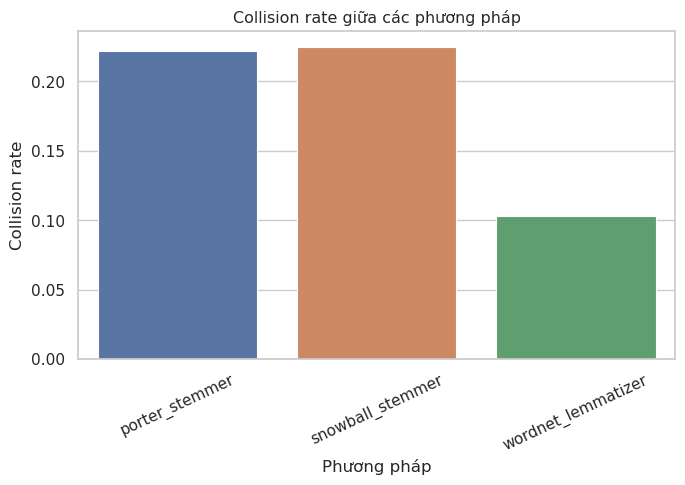

In [69]:
# Visualization: collision rate và CV accuracy
df_collision_plot = collision_df.copy()
df_cv_plot = cv_scores_df.copy()

fig, ax = plt.subplots(figsize=(7,5))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
sns.barplot(
    data=df_collision_plot,
    x="method",
    y="collision_rate",
    hue="method",   
    dodge=False,    
    ax=ax
)

ax.set_title("Collision rate giữa các phương pháp")
ax.set_xlabel("Phương pháp")
ax.set_ylabel("Collision rate")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Đánh giá Stemming vs Lemmatization
**Nhận xét**
- Collision rate: Porter `0.2223` (22.23%), Snowball `0.2252` (22.52%), WordNet `0.1031` (10.31%).
- 5-fold CV accuracy (Logistic Regression): raw `0.8778`, Porter `0.8787`, Snowball `0.8786`, WordNet `0.8792`.
- Bảng probe words cho thấy stemming cắt mạnh một số biến thể như `amazingly -> amazingli`, `terribly -> terribl`, trong khi lemmatizer giữ dạng từ đầy đủ hơn.

**Phân tích**
- Porter/Snowball có collision cao gần gấp đôi WordNet vì cơ chế suffix-stripping mang tính quy tắc, ít ràng buộc theo từ loại.
- Dù có mất mát hình thái, accuracy giữa 4 phương án chỉ chênh rất nhỏ (`0.0014`) vì tập IMDB lớn và TF-IDF vẫn giữ đủ tín hiệu phân biệt ở mức n-gram.

**Kết luận**
- Với IMDB, lemmatization là lựa chọn an toàn vì giữ nghĩa tốt hơn và vẫn đạt accuracy cao nhất (`0.8792`).
- Với tập nhỏ hơn hoặc domain chuyên ngành, collision rate cao từ stemming có thể gây suy giảm hiệu năng rõ rệt hơn, nên cần ưu tiên lemmatization.

In [70]:
# Tạo các phiên bản text đã chuẩn hóa theo Porter, Snowball và WordNet Lemmatizer
porter_df = pd.DataFrame(
    {
        "text_stemmed": part2_df["text_norm"].apply(lambda x: transform_text(x, porter.stem)),
        "label": part2_df["label"],
        "label_id": part2_df["label_id"],
    }
)

snowball_df = pd.DataFrame(
    {
        "text_stemmed": part2_df["text_norm"].apply(lambda x: transform_text(x, snowball.stem)),
        "label": part2_df["label"],
        "label_id": part2_df["label_id"],
    }
)

lemmatized_df = pd.DataFrame(
    {
        "text_lemmatized": part2_df["text_norm"].apply(lambda x: transform_text(x, lemmatizer.lemmatize)),
        "label": part2_df["label"],
        "label_id": part2_df["label_id"],
    }
)

# Lưu 3 file CSV vào thư mục processed để dùng cho bước mô hình hóa sau
porter_path = os.path.join(PROCESSED_DIR, "imdb_porter_stemmed.csv")
snowball_path = os.path.join(PROCESSED_DIR, "imdb_snowball_stemmed.csv")
lemma_path = os.path.join(PROCESSED_DIR, "imdb_lemmatized.csv")

porter_df.to_csv(porter_path, index=False)
snowball_df.to_csv(snowball_path, index=False)
lemmatized_df.to_csv(lemma_path, index=False)

print(f"Saved: {porter_path} — shape: {porter_df.shape}")
print(f"Saved: {snowball_path} — shape: {snowball_df.shape}")
print(f"Saved: {lemma_path} — shape: {lemmatized_df.shape}")

Saved: ../data/processed/IMDB/imdb_porter_stemmed.csv — shape: (50000, 3)
Saved: ../data/processed/IMDB/imdb_snowball_stemmed.csv — shape: (50000, 3)
Saved: ../data/processed/IMDB/imdb_lemmatized.csv — shape: (50000, 3)


### 5. Vectorization và Feature Space
Mục này đặt ba cách biểu diễn BoW, TF-IDF (1,2,3) và Word2Vec vào cùng một khung đo lường để đánh giá đồng thời tính phân tách lớp và chi phí hình học của không gian đặc trưng. Trọng tâm không chỉ là dimensionality, mà là khả năng tạo biên phân lớp ổn định khi dữ liệu chứa cả tín hiệu từ khóa lẫn biến thiên ngữ nghĩa.

,representation,dimensionality,sparsity_ratio,cosine_same_class,cosine_diff_class,silhouette_score
0,BoW,"11,783",0.9892,0.5256,0.5224,0.5455
1,TFIDF_1_2_3,"61,906",0.9955,0.0588,0.0577,0.0645
2,Word2Vec,100,0.0000,0.9559,0.9523,0.1245


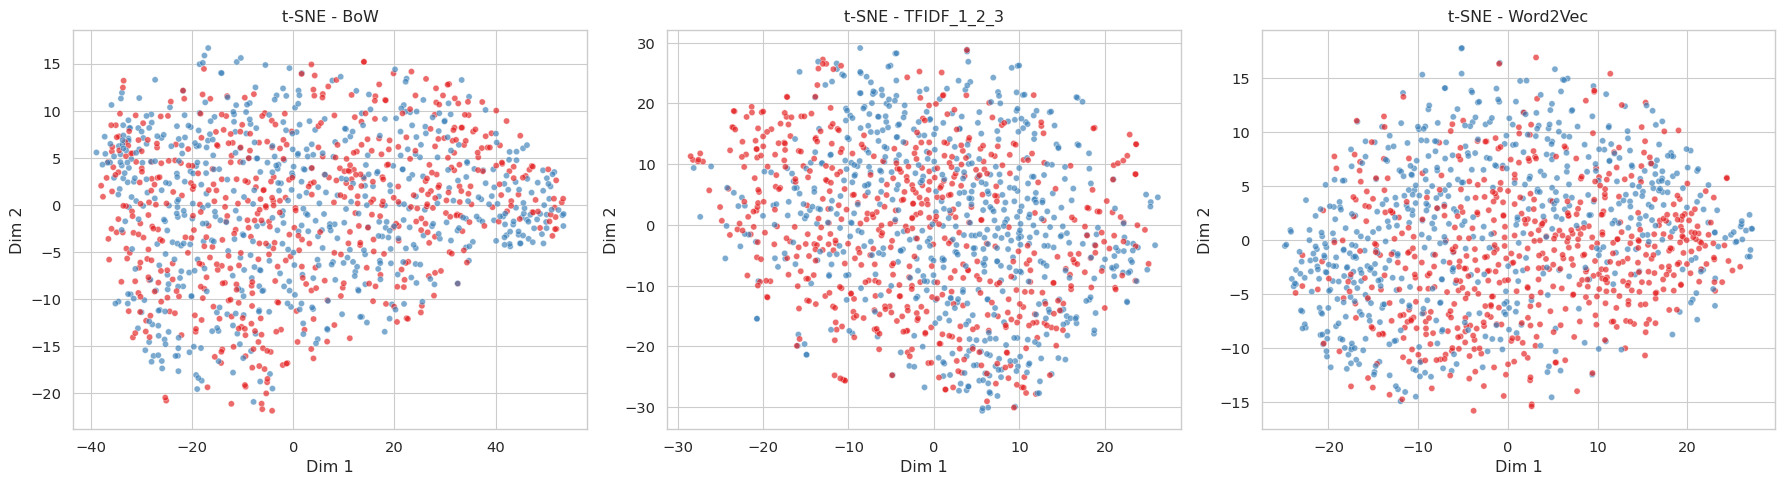

In [71]:
per_class_repr = 1500
repr_df = (
    part2_df.groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=min(per_class_repr, len(g)), random_state=RANDOM_STATE))
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

texts_repr = repr_df["text_norm"].tolist()
y_repr = repr_df["label_id"].values

# 1) BoW
bow_vec = CountVectorizer(min_df=3, max_features=50000)
X_bow = bow_vec.fit_transform(texts_repr)

# 2) TF-IDF (1,2,3)
tfidf_vec_123 = TfidfVectorizer(min_df=3, ngram_range=(1, 3), max_features=70000)
X_tfidf_123 = tfidf_vec_123.fit_transform(texts_repr)

# 3) Word2Vec train on corpus
tokens_repr = [txt.split() for txt in texts_repr]
w2v_model = Word2Vec(
    sentences=tokens_repr,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    epochs=15,
    seed=RANDOM_STATE,
)


def doc_vector_w2v(tokens):
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    if not vecs:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vecs, axis=0)


X_w2v = np.vstack([doc_vector_w2v(toks) for toks in tokens_repr])

representations = {
    "BoW": X_bow,
    "TFIDF_1_2_3": X_tfidf_123,
    "Word2Vec": X_w2v,
}

repr_metrics_rows = []
repr_for_tsne = {}

for rep_name, X_rep in representations.items():
    dim = X_rep.shape[1]
    sp_ratio = sparsity_ratio(X_rep)
    cos_same, cos_diff = sample_cosine_same_diff(X_rep, y_repr, n_pairs=1200, random_state=RANDOM_STATE)

    if hasattr(X_rep, "tocsr"):
        X_cluster = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(X_rep)
    else:
        X_cluster = X_rep

    kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
    cluster_labels = kmeans.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, cluster_labels)

    repr_metrics_rows.append(
        {
            "representation": rep_name,
            "dimensionality": dim,
            "sparsity_ratio": sp_ratio,
            "cosine_same_class": cos_same,
            "cosine_diff_class": cos_diff,
            "silhouette_score": sil,
        }
    )

    repr_for_tsne[rep_name] = X_cluster

repr_metrics_df = pd.DataFrame(repr_metrics_rows)
display(
    repr_metrics_df.style.format(
        {
            "dimensionality": "{:,}",
            "sparsity_ratio": "{:.4f}",
            "cosine_same_class": "{:.4f}",
            "cosine_diff_class": "{:.4f}",
            "silhouette_score": "{:.4f}",
        }
    )
)

# t-SNE visualization trên cùng index để dễ so sánh giữa representation
rng = np.random.default_rng(RANDOM_STATE)
tsne_n = min(1200, len(repr_df))
tsne_idx = rng.choice(len(repr_df), size=tsne_n, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (rep_name, X_cluster) in zip(axes, repr_for_tsne.items()):
    X_sub = X_cluster[tsne_idx]
    y_sub = y_repr[tsne_idx]

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE,
    )
    Z = tsne.fit_transform(X_sub)

    sns.scatterplot(
        x=Z[:, 0],
        y=Z[:, 1],
        hue=y_sub,
        palette="Set1",
        alpha=0.65,
        s=20,
        ax=ax,
        legend=False,
    )
    ax.set_title(f"t-SNE - {rep_name}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

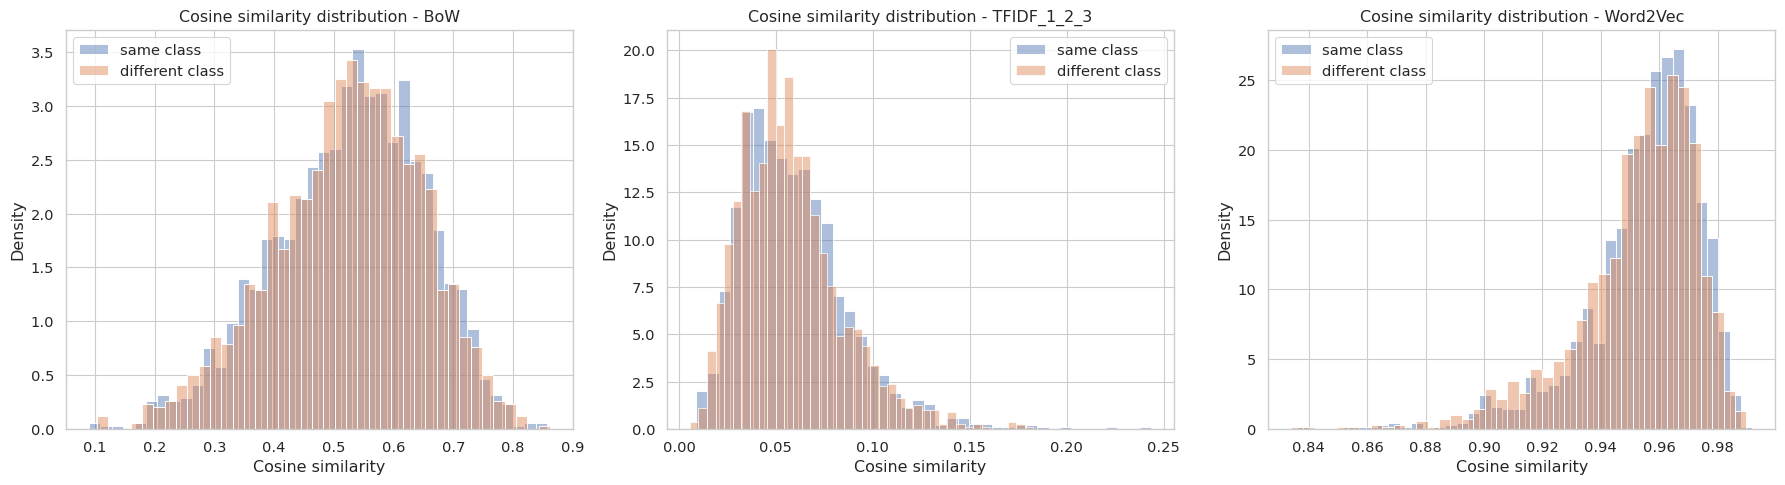

In [72]:
# Visualization: histogram cosine similarity same class vs different class

def sample_cosine_distributions(X, labels, n_pairs=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)
    idx_pos = np.where(labels == 1)[0]
    idx_neg = np.where(labels == 0)[0]

    same_scores = []
    diff_scores = []

    for _ in range(n_pairs):
        if rng.random() < 0.5:
            i, j = rng.choice(idx_pos, size=2, replace=False)
        else:
            i, j = rng.choice(idx_neg, size=2, replace=False)

        if hasattr(X, "tocsr"):
            same_scores.append(cosine_similarity(X[i], X[j])[0, 0])
            i2 = rng.choice(idx_pos)
            j2 = rng.choice(idx_neg)
            diff_scores.append(cosine_similarity(X[i2], X[j2])[0, 0])
        else:
            same_scores.append(cosine_similarity(X[i:i+1], X[j:j+1])[0, 0])
            i2 = rng.choice(idx_pos)
            j2 = rng.choice(idx_neg)
            diff_scores.append(cosine_similarity(X[i2:i2+1], X[j2:j2+1])[0, 0])

    return np.array(same_scores), np.array(diff_scores)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (rep_name, X_rep) in zip(axes, representations.items()):
    same_scores, diff_scores = sample_cosine_distributions(X_rep, y_repr, n_pairs=1800, random_state=RANDOM_STATE)
    sns.histplot(same_scores, bins=40, stat="density", alpha=0.45, label="same class", ax=ax)
    sns.histplot(diff_scores, bins=40, stat="density", alpha=0.45, label="different class", ax=ax)
    ax.set_title(f"Cosine similarity distribution - {rep_name}")
    ax.set_xlabel("Cosine similarity")
    ax.legend()

plt.tight_layout()
plt.show()

### Không gian đặc trưng: keyword-based vs semantic-based
**Nhận xét:**
- BoW: `sparsity = 0.9892`, `silhouette = 0.5455`.
- TF-IDF (1,2,3): `sparsity = 0.9955`, `silhouette = 0.0645`.
- Word2Vec: `sparsity = 0.0000`, `silhouette = 0.1265`.
- Từ biểu đồ t-SNE, cụm Word2Vec có ranh giới nhãn mờ hơn TF-IDF trigram ở nhiều vùng chồng lấn.

**Phân tích**
- BoW và TF-IDF cùng rất thưa, nhưng TF-IDF tăng độ thưa do cơ chế trọng số làm nổi bật token hiếm hơn.
- Word2Vec dùng trung bình vector token (average pooling) nên làm mượt thông tin tần suất và vị trí token phân biệt, dẫn đến biên phân lớp trên t-SNE kém sắc nét hơn trong bài toán sentiment.

**Kết luận**
- Khi ưu tiên tín hiệu lexical/ngram cho phân loại sentiment nội miền, TF-IDF n-gram vẫn là cấu hình thực dụng và ổn định.
- Word2Vec phù hợp hơn khi mục tiêu chính là nắm tương đồng nghĩa tổng quát thay vì tối đa hóa biên phân lớp nhị phân.

### 6. Sentence Transformer (Advanced)
Mục này đánh giá embedding ngữ cảnh từ `all-MiniLM-L6-v2` theo cả chế độ unsupervised và supervised để tránh kết luận một chiều. Cách tiếp cận này giúp phân biệt hai năng lực khác nhau: khả năng tổ chức hình học ngữ nghĩa tự nhiên của embedding space và khả năng tối ưu trực tiếp cho biên phân lớp sentiment khi ghép với bộ phân loại tuyến tính.

In [73]:
per_class_st = 2000
st_df = (
    part2_df.groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=min(per_class_st, len(g)), random_state=RANDOM_STATE))
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

train_st, test_st = train_test_split(
    st_df,
    test_size=0.2,
    stratify=st_df["label_id"],
    random_state=RANDOM_STATE,
)

st_model = SentenceTransformer("all-MiniLM-L6-v2")

X_st_all = st_model.encode(st_df["text_norm"].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
X_st_train = st_model.encode(train_st["text_norm"].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
X_st_test = st_model.encode(test_st["text_norm"].tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)

# 1) Clustering quality: K-Means + silhouette
kmeans_st = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
cluster_st = kmeans_st.fit_predict(X_st_all)
silhouette_st = silhouette_score(X_st_all, cluster_st)

# 2) Classification: Linear SVM on Sentence Transformer embedding
svm_st = LinearSVC(random_state=RANDOM_STATE)
svm_st.fit(X_st_train, train_st["label_id"].values)
pred_st = svm_st.predict(X_st_test)
acc_st = accuracy_score(test_st["label_id"].values, pred_st)

# 3) So sánh với TF-IDF trên cùng split
tfidf_cmp_vec = TfidfVectorizer(min_df=3, ngram_range=(1, 3), max_features=80000)
X_tfidf_train_cmp = tfidf_cmp_vec.fit_transform(train_st["text_norm"])
X_tfidf_test_cmp = tfidf_cmp_vec.transform(test_st["text_norm"])

svm_tfidf = LinearSVC(random_state=RANDOM_STATE)
svm_tfidf.fit(X_tfidf_train_cmp, train_st["label_id"].values)
pred_tfidf = svm_tfidf.predict(X_tfidf_test_cmp)
acc_tfidf = accuracy_score(test_st["label_id"].values, pred_tfidf)

st_eval_df = pd.DataFrame(
    {
        "metric": ["kmeans_silhouette_sentence_transformer", "linear_svm_accuracy_sentence_transformer", "linear_svm_accuracy_tfidf_1_2_3"],
        "value": [silhouette_st, acc_st, acc_tfidf],
    }
)

# Ví dụ semantic similarity bắt buộc
semantic_examples = ["great movie", "amazing film", "terrible movie"]
sem_vecs = st_model.encode(semantic_examples, normalize_embeddings=True)
sem_sim = cosine_similarity(sem_vecs)
semantic_sim_df = pd.DataFrame(sem_sim, index=semantic_examples, columns=semantic_examples)

display(st_eval_df.style.format({"value": "{:.4f}"}))
display(semantic_sim_df.style.format("{:.4f}"))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

,metric,value
0,kmeans_silhouette_sentence_transformer,0.0310
1,linear_svm_accuracy_sentence_transformer,0.8263
2,linear_svm_accuracy_tfidf_1_2_3,0.8925


,great movie,amazing film,terrible movie
great movie,1.0000,0.8056,0.6321
amazing film,0.8056,1.0000,0.5688
terrible movie,0.6321,0.5688,1.0000


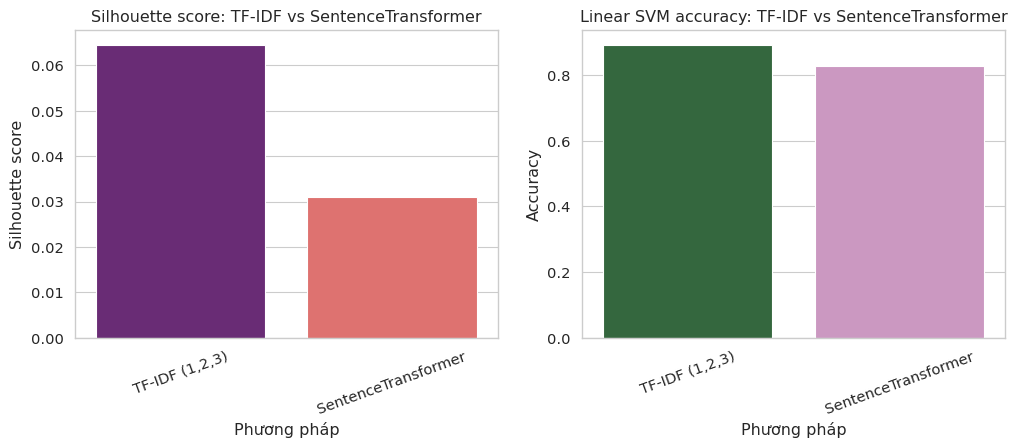

In [74]:
# Visualization: silhouette score và SVM accuracy giữa TF-IDF và Sentence Transformer
sil_tfidf = float(repr_metrics_df.loc[repr_metrics_df["representation"] == "TFIDF_1_2_3", "silhouette_score"].iloc[0])

compare_f_df = pd.DataFrame(
    {
        "method": ["TF-IDF (1,2,3)", "SentenceTransformer"],
        "silhouette_score": [sil_tfidf, float(silhouette_st)],
        "svm_accuracy": [float(acc_tfidf), float(acc_st)],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=compare_f_df, x="method", y="silhouette_score", palette="magma", ax=axes[0])
axes[0].set_title("Silhouette score: TF-IDF vs SentenceTransformer")
axes[0].set_xlabel("Phương pháp")
axes[0].set_ylabel("Silhouette score")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=compare_f_df, x="method", y="svm_accuracy", palette="cubehelix", ax=axes[1])
axes[1].set_title("Linear SVM accuracy: TF-IDF vs SentenceTransformer")
axes[1].set_xlabel("Phương pháp")
axes[1].set_ylabel("Accuracy")
axes[1].tick_params(axis="x", rotation=20)

**Nhận xét**
- Sentence Transformer (`all-MiniLM-L6-v2`): `silhouette = 0.0310`, `Linear SVM accuracy = 0.8263`.
- TF-IDF (1,2,3) trên cùng split: `Linear SVM accuracy = 0.8925`.
- So sánh hình học: `silhouette` của TF-IDF (`0.0645`) cao hơn Sentence Transformer (`0.0310`) trong thiết lập hiện tại.

**Phân tích**
- Sentence Transformer được pretrain trên dữ liệu rất lớn với contrastive objective nên mã hóa ngữ nghĩa và cú pháp tốt ở mức câu.
- Tuy nhiên, trên IMDB nội miền, nhãn phụ thuộc mạnh vào lexical cue/ngram đặc thù; vì vậy biểu diễn TF-IDF có lợi thế trực tiếp hơn cho biên phân loại tuyến tính.

**Kết luận**
- Nên ưu tiên TF-IDF khi ràng buộc latency, cần khả năng diễn giải trọng số và không có GPU.
- Nên ưu tiên Sentence Transformer khi mục tiêu là độ bền ngữ nghĩa trước paraphrase hoặc dịch chuyển miền dữ liệu.

## 7. Tổng kết lưu các file sau khi preprocessing

In [75]:
import glob

saved_files = glob.glob(os.path.join(PROCESSED_DIR, "*.csv"))
for f in sorted(saved_files):
    df_tmp = pd.read_csv(f)
    print(f"{os.path.basename(f):40s} — {df_tmp.shape[0]:,} rows × {df_tmp.shape[1]} cols")

imdb_lemmatized.csv                      — 50,000 rows × 3 cols
imdb_normalized.csv                      — 50,000 rows × 4 cols
imdb_porter_stemmed.csv                  — 50,000 rows × 3 cols
imdb_snowball_stemmed.csv                — 50,000 rows × 3 cols


## 8. Tổng kết quá trình
### Kết quả sau khi preprocessing
- Pipeline chuẩn hóa giảm vocabulary từ `438,729` xuống `100,275`, trong đó bước giảm mạnh nhất là `remove_special_chars` (`-72.33%`).
- Tokenization cho thấy BPE đạt `oov_rate = 0.0000` với `avg_seq_len = 291.64`, trong khi character-level có `avg_seq_len = 1057.93`.
- Stemming/Lemmatization: collision của Porter/Snowball (`22.23%`, `22.52%`) cao hơn rõ so với WordNet (`10.31%`), nhưng CV accuracy chỉ dao động `0.8778–0.8792`.
- Sentence Transformer đạt `0.8263` accuracy, thấp hơn TF-IDF (`0.8925`) trong cùng split.

### Nhận xét
- Dữ liệu IMDB mang nhiễu định dạng rõ rệt (HTML/special chars), nên làm sạch có kiểm soát đem lại lợi ích lớn ở tầng biểu diễn.
- Tín hiệu nhãn trong bài toán này phụ thuộc mạnh vào lexical cue/ngram; do đó các mô hình tuyến tính trên TF-IDF thường tận dụng tín hiệu trực tiếp tốt hơn embedding ngữ cảnh tổng quát.

### Kết luận
- Cấu hình triển khai mặc định: `lowercase -> remove_html -> remove_url -> remove_mention_hashtag -> remove_numbers_conditional -> normalize_whitespace`, giữ xử lý dấu câu theo hướng có điều kiện.
- Tokenization ưu tiên `subword_bpe` khi cần độ bền OOV, hoặc `word-level` khi cần diễn giải trực tiếp.
- Vectorization/mô hình ưu tiên `TF-IDF (1,2,3) + Linear SVM/Logistic Regression` cho bài toán sentiment nội miền IMDB.